# 1. Setup

In [ ]:
# Imports
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.special import expit 
from scipy.optimize import minimize 
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, wilcoxon, friedmanchisquare

In [ ]:
# Reproducibility
RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)

In [ ]:
# Project paths
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "PD_data"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = PROJECT_DIR / "figures"

# Create output directories if they do not exist
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

In [ ]:
# Dataset settings
RUN_A_KEY = "data_train"
RUN_B_KEY = "data_test"

N_EXPECTED_PARTICIPANTS = 49

# 2. Data loading and preparation

In [ ]:
# Load participant files
mat_files = sorted(DATA_DIR.glob("*.mat"))

assert DATA_DIR.exists(), f"Data direcotry not found: {DATA_DIR}"
assert len(mat_files) == N_EXPECTED_PARTICIPANTS, (
    f"Expected {N_EXPECTED_PARTICIPANTS} participant files, "
    f"but found {len(mat_files)}."
)
print("Number of participant files:", len(mat_files))
print("First file:", mat_files[0].name)

Number of participant files: 49
First file: 2rrjzhgj9.mat


In [ ]:
# Check one file
example = sio.loadmat(mat_files[0])

print(example.keys()) 
print("Run A shape:", example[RUN_A_KEY].shape) 
print("Run B shape:", example[RUN_B_KEY].shape) 
print("Labels:", example["data_labels"])

dict_keys(['__header__', '__version__', '__globals__', 'data_labels', 'data_test', 'data_train'])
Run A shape: (200, 8)
Run B shape: (200, 8)
Labels: [[array(['certOutcome'], dtype='<U11')
  array(['uncOutcome'], dtype='<U10')
  array(['outcome prob.'], dtype='<U13')
  array(['action (1=certain, 2=uncertain, 0=missing)'], dtype='<U42')
  array(['p_cert'], dtype='<U6')
  array(['condition (1=reward,2=loss)'], dtype='<U27')
  array(['RT'], dtype='<U2') array(['odds'], dtype='<U4')]]


In [ ]:
# Column indices
COL_R_CERT = 0      # 0 = certain outcome
COL_R_UNCERT = 1    # 1 = uncertain outcome
COL_P = 2           # 2 = outcome probability
COL_CHOICE = 3      # 3 = action, where 1=certain, 2=uncertain, 0=missing
COL_P_CERT = 4
COL_CONDITION = 5   # 5 = condition, where 1=reward, 2=loss
COL_RT = 6          # 6 = reaction time
COL_ODDS = 7

In [ ]:
# Prepare trial data
def prepare_data(data):
    data = np.asarray(data, dtype=float)

    # Remove missing choices and invalid RTs
    valid = (
        np.isin(data[:, COL_CHOICE], [1, 2])
        & np.isfinite(data[:, COL_RT]) 
        & (data[:, COL_RT] > 0) 
    )
    data = data[valid]

    r_cert = data[:, COL_R_CERT]
    r_uncert = data[:, COL_R_UNCERT]
    p = data[:, COL_P]
    choice = data[:, COL_CHOICE]
    condition = data[:, COL_CONDITION]
    rt = data[:, COL_RT]
    
    # Convert probabilities from percentages to proportions
    if np.nanmax(p) > 1: 
        p = p / 100.0
        
    # Recode choice:
    # original 1 = certain -> y = 1 
    # original 2 = uncertain -> y = 0 
    y = (choice == 1).astype(int)

    return r_cert, r_uncert, p, y, rt, condition

In [ ]:
# Sanity checks
summary = []

for file in mat_files:
    participant = sio.loadmat(file)

    for run_name, run_key in [("Run A", RUN_A_KEY), ("Run B", RUN_B_KEY)]:
        data = np.asarray(participant[run_key], dtype=float)

        choice = data[:, COL_CHOICE]
        condition = data[:, COL_CONDITION]
        rt = data[:, COL_RT]

        choice_missing = (choice == 0) | ~np.isfinite(choice)
        rt_missing = ~np.isfinite(rt)

        summary.append({
            "participant": file.stem,
            "run": run_name,
            "n_trials": len(data),
            "missing_choice": choice_missing.sum(),
            "missing_rt": rt_missing.sum(),
            "choice_missing_rt_valid": np.sum(choice_missing & ~rt_missing),
            "choice_valid_rt_missing": np.sum(~choice_missing & rt_missing),
            "choice_missing_rt_missing": np.sum(choice_missing & rt_missing),
            "nonpositive_rt": np.sum(np.isfinite(rt) & (rt <= 0)),
            "reward_trials": np.sum(condition == 1),
            "loss_trials": np.sum(condition == 2)
        })

sanity_df = pd.DataFrame(summary)

display(sanity_df.groupby("run").agg({
    "n_trials": "sum",
    "missing_choice": "sum",
    "missing_rt": "sum",
    "choice_missing_rt_valid": "sum",
    "choice_valid_rt_missing": "sum",
    "choice_missing_rt_missing": "sum",
    "nonpositive_rt": "sum",
    "reward_trials": "sum",
    "loss_trials": "sum",    
}))

,n_trials,missing_choice,missing_rt,choice_missing_rt_valid,choice_valid_rt_missing,choice_missing_rt_missing,nonpositive_rt,reward_trials,loss_trials
run,,,,,,,,,
Run A,9800,51,51,0,0,51,0,4900,4900
Run B,9800,17,17,0,0,17,0,4900,4900


## Basic descriptives

In [ ]:
def compute_basic_descriptives(mat_files):
    """Compute choice and RT descriptives by run and condition."""
    rows = []
    for file in mat_files:
        participant = sio.loadmat(file)
        for run_name, run_key in [("Run A", RUN_A_KEY), ("Run B", RUN_B_KEY)]:
            data = participant[run_key]
            _, _, _, y, rt, condition = prepare_data(data)
            for condition_value, condition_label in [(1, "reward"), (2, "loss")]:
                mask = condition == condition_value
                rows.append({
                    "participant": file.stem,
                    "run": run_name,
                    "condition": condition_label,
                    "n_trials": mask.sum(),
                    "certain_choice_proportion": y[mask].mean(),
                    "mean_rt": rt[mask].mean(),
                    "median_rt": np.median(rt[mask]),
                    "std_rt": rt[mask].std(ddof=1),
                    "rt_q05": np.quantile(rt[mask], 0.05),
                    "rt_q95": np.quantile(rt[mask], 0.95)
                })
    return pd.DataFrame(rows)

In [ ]:
basic_descriptives = compute_basic_descriptives(mat_files)
basic_descriptives.head()

,participant,run,condition,n_trials,certain_choice_proportion,mean_rt,median_rt,std_rt,rt_q05,rt_q95
0,2rrjzhgj9,Run A,reward,99,0.414141,2501.584848,2267.70,1299.541548,1413.180,3971.570
1,2rrjzhgj9,Run A,loss,100,0.530000,2419.590000,2322.10,717.064108,1331.150,3735.680
2,2rrjzhgj9,Run B,reward,100,0.590000,2032.914000,1673.65,1459.732253,930.990,4346.240
3,2rrjzhgj9,Run B,loss,100,0.560000,2331.486000,2094.70,1195.778142,1012.445,4779.440
4,3lmzwis6r,Run A,reward,100,0.450000,3003.521000,2828.55,1283.768528,1488.580,5320.155


In [ ]:
basic_descriptives_summary = (
    basic_descriptives.groupby(["run", "condition"])
    .agg(participants=("participant", "nunique"),
         mean_valid_trials=("n_trials", "mean"),

         mean_certain_choice_proportion=("certain_choice_proportion", "mean"),
         sd_certain_choice_proportion=("certain_choice_proportion", "std"),

         mean_participant_mean_rt=("mean_rt", "mean"),
         median_participant_median_rt=("median_rt", "median"),
         mean_participant_rt_sd=("std_rt", "mean"),
         
         median_participant_rt_q05=("rt_q05", "median"),
         median_participant_rt_q95=("rt_q95", "median"))
    .reset_index()
)
basic_descriptives_summary

,run,condition,participants,mean_valid_trials,mean_certain_choice_proportion,sd_certain_choice_proportion,mean_participant_mean_rt,median_participant_median_rt,mean_participant_rt_sd,median_participant_rt_q05,median_participant_rt_q95
0,Run A,loss,49,99.183673,0.614329,0.137350,2737.264323,2450.5,1190.094185,1271.54,5029.290
1,Run A,reward,49,99.775510,0.597717,0.176422,2299.871598,2038.9,1052.056967,1188.46,4108.885
2,Run B,loss,49,99.775510,0.519980,0.169679,2060.173486,1833.9,955.503185,1031.05,3877.700
3,Run B,reward,49,99.877551,0.474191,0.205190,1854.191345,1708.5,886.754204,1070.92,3525.750


In [ ]:
def collect_rt_by_run_condition(mat_files):
    """Collect valid RTs by run and condition."""
    rows = []
    for file in mat_files:
        participant = sio.loadmat(file)
        for run_name, run_key in [("Run A", RUN_A_KEY), ("Run B", RUN_B_KEY)]:
            data = participant[run_key]

            _, _, _, _, rt, condition = prepare_data(data)

            for rt_value, condition_value in zip(rt, condition):
                rows.append({
                    "run": run_name,
                    "condition": ("reward" if condition_value == 1 else "loss"),
                    "rt": rt_value
                })
    return pd.DataFrame(rows)

In [ ]:
rt_descriptive_data = collect_rt_by_run_condition(mat_files)

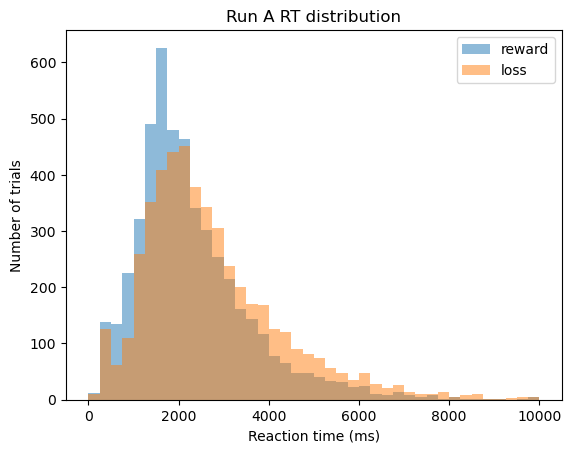

In [ ]:
bins = np.linspace(0, 10000, 41)

for condition in ["reward", "loss"]:
    values = rt_descriptive_data.loc[
        (rt_descriptive_data["run"] == "Run A") 
        & (rt_descriptive_data["condition"] == condition),
        "rt"
    ]
    plt.hist(values, bins=bins, alpha=0.5, label=condition)
plt.xlabel("Reaction time (ms)")
plt.ylabel("Number of trials")
plt.title("Run A RT distribution")
plt.legend()
plt.show()

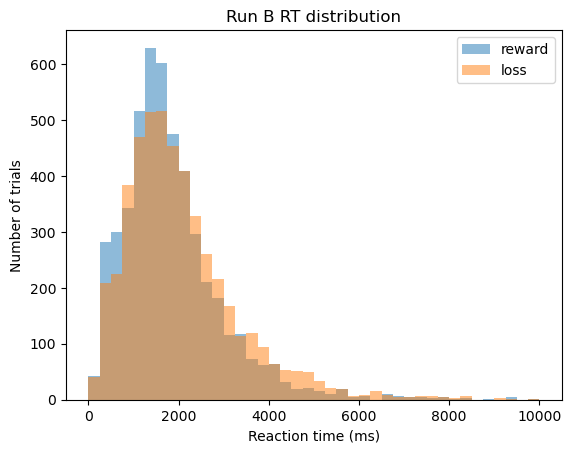

In [ ]:
for condition in ["reward", "loss"]:
    values = rt_descriptive_data.loc[
        (rt_descriptive_data["run"] == "Run B") 
        & (rt_descriptive_data["condition"] == condition),
        "rt"
    ]
    plt.hist(values, bins=bins, alpha=0.5, label=condition)
plt.xlabel("Reaction time (ms)")
plt.ylabel("Number of trials")
plt.title("Run B RT distribution")
plt.legend()
plt.show()

# 3. Shared Model Components

In [ ]:
# Hyperbolic subjective valuation
def compute_subjective_values(r_cert, r_uncert, p, h): 
    """Compute subjective values under hyperbolic probability discounting."""

    eps = 1e-12
    p = np.clip(p, eps, 1 - eps) 
    
    theta = (1 - p) / p
    
    v_cert = r_cert
    v_uncert = r_uncert / (1 + h * theta)
    
    return v_cert, v_uncert

In [ ]:
# Subjective value difference
def compute_value_difference(v_cert, v_uncert):
    """Compute subjective value difference."""
    return v_cert - v_uncert

In [ ]:
# Logistic choice rule
def compute_choice_probability(delta_v, beta):
    """Compute probability of choosing the certain option."""
    return expit(beta * delta_v)

In [ ]:
# Bernoulli choice log-likelihood
def choice_log_likelihood(y, pi):
    """Bernoulli log-likelihood for binary choices."""

    eps = 1e-12
    pi = np.clip(pi, eps, 1 - eps)

    return np.sum(y * np.log(pi) + (1 - y) * np.log(1 - pi))

In [ ]:
# Shifted log-normal RT likelihood
def shifted_lognormal_log_likelihood(rt, mu, sigma, tau):
    """Log-likelihood of RT under a shifted log-normal distribution."""

    if sigma <= 0 or tau < 0:
        return -np.inf

    rt_shifted = rt - tau

    if np.any(rt_shifted <= 0):
        return -np.inf

    log_rt = np.log(rt_shifted)

    return np.sum(-np.log(rt_shifted) - np.log(sigma) - 0.5 * np.log(2 * np.pi) - ((log_rt - mu) ** 2) / (2 * sigma ** 2))

# 4. Model Specifications

## Choice-only model:

In [ ]:
def nll_choice_only(params, data): 

    beta, h = params

    # Safety check
    if beta < 0 or h < 0:
        return np.inf

    # Prepare data
    r_cert, r_uncert, p, y, _, _ = prepare_data(data)

    # Shared valuation
    v_cert, v_uncert = compute_subjective_values(r_cert, r_uncert, p, h) 

    # Delta V
    delta_v = compute_value_difference(v_cert, v_uncert)

    # Choice probability
    pi = compute_choice_probability(delta_v, beta)

    # Bernoulli choice likelihood
    log_likelihood_choice = choice_log_likelihood(y, pi)
    
    return -log_likelihood_choice

## RT model 1: Absolute conflict

Combine choice model with absolute conflict.

In [ ]:
def nll_absolute_conflict(params, data): 

    beta, h, a, b, sigma, tau = params

    # Safety check
    if beta < 0 or b < 0 or h < 0: 
        return np.inf
    
    r_cert, r_uncert, p, y, rt, _ = prepare_data(data)

    v_cert, v_uncert = compute_subjective_values(r_cert, r_uncert, p, h)
    delta_v = compute_value_difference(v_cert, v_uncert)

    pi = compute_choice_probability(delta_v, beta)
    log_likelihood_choice = choice_log_likelihood(y, pi)

    # Absolute conflict
    conflict = np.abs(delta_v)
    mu = a - b * conflict

    log_likelihood_rt = shifted_lognormal_log_likelihood(rt, mu, sigma, tau)
    total_log_likelihood = log_likelihood_choice + log_likelihood_rt 

    return -total_log_likelihood

## RT model 2: Squared conflict

Combine choice model with squared conflict.

In [ ]:
def nll_squared_conflict(params, data): 

    beta, h, a, b, sigma, tau = params

    # Safety check
    if beta < 0 or b < 0 or h < 0: 
        return np.inf
    
    r_cert, r_uncert, p, y, rt, _ = prepare_data(data)

    v_cert, v_uncert = compute_subjective_values(r_cert, r_uncert, p, h)
    delta_v = compute_value_difference(v_cert, v_uncert)

    pi = compute_choice_probability(delta_v, beta)
    log_likelihood_choice = choice_log_likelihood(y, pi)

    # Squared conflict
    conflict = delta_v ** 2
    mu = a - b * conflict

    log_likelihood_rt = shifted_lognormal_log_likelihood(rt, mu, sigma, tau)
    total_log_likelihood = log_likelihood_choice + log_likelihood_rt 

    return -total_log_likelihood

## RT model 3: Exponential value-difference mapping

Combine choice model with exponential mapping.

In [ ]:
def nll_exponential_conflict(params, data): 

    beta, h, a, b, sigma, tau = params

    # Safety check
    if beta < 0 or b < 0 or h < 0: 
        return np.inf
    
    r_cert, r_uncert, p, y, rt, _ = prepare_data(data)

    v_cert, v_uncert = compute_subjective_values(r_cert, r_uncert, p, h)
    delta_v = compute_value_difference(v_cert, v_uncert)

    pi = compute_choice_probability(delta_v, beta)
    log_likelihood_choice = choice_log_likelihood(y, pi)

    # Exponential mapping
    conflict = np.exp(-(delta_v ** 2))
    mu = a + b * conflict

    log_likelihood_rt = shifted_lognormal_log_likelihood(rt, mu, sigma, tau)
    total_log_likelihood = log_likelihood_choice + log_likelihood_rt 

    return -total_log_likelihood

# 5. Model Fitting

## Shared fitting utilities

In [ ]:
# Optimization helpers
OPT_EPS = 1e-6

# Parameter names
CHOICE_PARAMETERS = ["beta", "h"]
FULL_PARAMETERS = ["beta", "h", "a", "b", "sigma", "tau"]

def is_valid_optimization_result(result):
    """Check whether an optimization result is usable."""
    return (
        result.success 
        and np.isfinite(result.fun) 
        and np.all(np.isfinite(result.x))
    )

def get_full_model_bounds(rt):
    """Return parameter bounds for the full choice + RT models."""
    min_rt = np.min(rt)

    bounds = [
        (0, None),              # beta
        (0, None),              # h
        (None, None),           # a
        (0, None),              # b
        (OPT_EPS, None),        # sigma
        (0, min_rt - OPT_EPS)   # tau
    ]

    return bounds

In [ ]:
def run_multistart_optimization(objective_function, data, initial_conditions, bounds):
    """Run multi-start L-BFGS-B optimization and return the best valid fit."""
    best_result = None
    all_results = []

    for x0 in initial_conditions:
        result = minimize(objective_function, 
                          x0=x0, 
                          args=(data,), 
                          method="L-BFGS-B", 
                          bounds=bounds, 
                          options={"maxiter": 500, "ftol": 1e-7}
                          )
        all_results.append(result)
        if (is_valid_optimization_result(result)
            and (best_result is None or result.fun < best_result.fun)):
            best_result = result
    return best_result, all_results

## Choice-only Model Fitting

In [ ]:
def initial_conditions_choice_only():
    """Generate starting points for the choice-only model."""
    beta_values = [0.001, 0.1, 1, 3, 10, 30, 100] 
    h_values = [0.001, 0.1, 1, 3, 10, 30, 100]
    initial_conditions = []
    for beta in beta_values: 
        for h in h_values:
            initial_conditions.append([beta, h]) 

    return initial_conditions

In [ ]:
def fit_choice_only(data):
    """Fit the choice-only model using multi-start L-BFGS-B optimization."""
    bounds = [(0, None), (0, None)] # beta, h
    initial_conditions = initial_conditions_choice_only()
    return run_multistart_optimization(nll_choice_only, data, initial_conditions, bounds)

## Shared RT initialization

In [ ]:
def data_informed_rt_start(data, beta_start, h_start, tau_start, model_name):
    """Create a data-informed starting point for one RT model."""
    r_cert, r_uncert, p, _, rt, _ = prepare_data(data)
    rt_shifted = rt - tau_start
    if np.any(rt_shifted <= 0):
        raise ValueError("tau_start must be smaller than all observed RTs.")
    log_rt = np.log(rt_shifted)

    # Subjective values at the proposed h
    v_cert, v_uncert = compute_subjective_values(r_cert, r_uncert, p, h_start)
    delta_v = compute_value_difference(v_cert, v_uncert)

    # Model-specific value-to-RT predictor
    if model_name == "absolute":
        predictor = np.abs(delta_v)
        slope, _ = np.polyfit(predictor, log_rt, 1)

        b0 = max(-slope, OPT_EPS)
        a0 =  np.mean(log_rt + b0 * predictor)
        mu0 = a0 - b0 * predictor

    elif model_name == "squared":
        predictor = (delta_v ** 2)
        slope, _ = np.polyfit(predictor, log_rt, 1)

        b0 = max(-slope, OPT_EPS)
        a0 =  np.mean(log_rt + b0 * predictor)
        mu0 = a0 - b0 * predictor

    elif model_name == "exponential":
        predictor = np.exp(-(delta_v ** 2))
        slope, _ = np.polyfit(predictor, log_rt, 1)

        b0 = max(slope, OPT_EPS)
        a0 =  np.mean(log_rt - b0 * predictor)
        mu0 = a0 + b0 * predictor

    else:
        raise ValueError(f"Unknown RT model: {model_name}")

    sigma0 = max(np.std(log_rt - mu0, ddof=1), OPT_EPS)

    return np.array([beta_start, h_start, a0, b0, sigma0, tau_start])

In [ ]:
def initial_conditions_rt_model(data, choice_result, model_name):
    """Generate local and global starting points for one RT model."""
    beta0, h0 = choice_result.x
    _, _, _, _, rt, _ = prepare_data(data)

    min_rt = np.min(rt)

    # Data-informed base solution
    base = data_informed_rt_start(
        data=data, beta_start=beta0, h_start=h0, tau_start=0.0, model_name=model_name)

    _, _, a0, b0, sigma0, _ = base

    # Vary selected parameters around the data-informed starting point
    beta_values = [beta0 * 0.5, beta0, beta0 * 2]
    h_values = [h0 * 0.5, h0, h0 * 2]
    b_values = [max(b0 * 0.5, OPT_EPS), b0, b0 * 2]
    tau_values = [0.0, 0.25 * min_rt, 0.5 * min_rt]

    initial_conditions = []

    # Create all combinations of beta, h, b, and tau starting values
    for beta in beta_values:
        for h in h_values:
            for b in b_values:
                for tau in tau_values:
                    initial_conditions.append(np.array([beta, h, a0, b, sigma0, tau]))

    # Global anchors
    global_h_values = [0.1, 1.0, 3.0, 10.0, 30.0, 100.0]
    global_beta_values = [0.0, beta0]
    global_tau_values = [0.0, 0.5 * min_rt]

    for h in global_h_values:
        for beta in global_beta_values:
            for tau in global_tau_values:
                global_start = (
                    data_informed_rt_start(
                        data=data, beta_start=beta, h_start=h, tau_start=tau, model_name=model_name
                    ))
                initial_conditions.append(global_start)

    return initial_conditions

## Model-specific initialization wrappers

In [ ]:
def initial_conditions_absolute(data, choice_result):
    """Generate starting points for the Absolute RT model."""
    return initial_conditions_rt_model(data, choice_result, "absolute")

In [ ]:
def initial_conditions_squared(data, choice_result):
    """Generate multiple starting points around a data-informed initial solution."""
    return initial_conditions_rt_model(data, choice_result, "squared")

In [ ]:
def initial_conditions_exponential(data, choice_result):
    """Generate multiple starting points around a data-informed initial solution."""
    return initial_conditions_rt_model(data, choice_result, "exponential")

## Shared full-model fitting

In [ ]:
RT_NLL_FUNCTIONS = {
    "absolute": nll_absolute_conflict,
    "squared": nll_squared_conflict,
    "exponential": nll_exponential_conflict
}

In [ ]:
def fit_rt_model(data, model_name, choice_result=None):
    """Fit one full choice + RT model using multi-start optimization."""
    _, _, _, _, rt, _ = prepare_data(data)
    bounds = get_full_model_bounds(rt)

    # Use choice-only estimates to inform local starts
    if choice_result is None:
        choice_result, _ = fit_choice_only(data)

    if choice_result is None:
        return None, []

    initial_conditions = (initial_conditions_rt_model(data, choice_result, model_name))
    objective_function = (RT_NLL_FUNCTIONS[model_name])

    return run_multistart_optimization(objective_function, data, initial_conditions, bounds)

## Model-specific fitting wrappers

In [ ]:
def fit_absolute(data, choice_result=None):
    """Fit the absolute RT model."""
    return fit_rt_model(data, "absolute", choice_result)

In [ ]:
def fit_squared(data, choice_result=None):
    """Fit the squared RT model."""
    return fit_rt_model(data, "squared", choice_result)

In [ ]:
def fit_exponential(data, choice_result = None):
    """Fit the exponential RT model."""
    return fit_rt_model(data, "exponential", choice_result)

# 6. Run A Inference

## Generic Run A fitting function

In [ ]:
def fit_model_run_a(fit_function, parameter_names, model_name):
    """Fit one model to Run A for all participants and store the estimates."""

    results = []

    for i, file in enumerate(mat_files):
        participant = sio.loadmat(file)
        data_run_a = participant[RUN_A_KEY]

        # Fit the model to Run A
        best_result, all_results = fit_function(data_run_a)

        # Count valid optimization starts
        n_successful = sum(
            is_valid_optimization_result(result)
            for result in all_results
        )

        row = {
            "participant": file.stem,
            "model": model_name,
            "fit_success": best_result is not None,
            "successful_starts": n_successful,
            "total_starts": len(all_results)
        }

        # Store parameter estimates if fitting succeeded
        if best_result is not None:
            row["nll"] = best_result.fun

            for name, value in zip(parameter_names, best_result.x):
                row[name] = value

        results.append(row)

        print(f"[{i + 1}/{len(mat_files)}] {model_name} Run A: {file.stem}")

    return pd.DataFrame(results)

## Choice-only baseline

In [ ]:
# Run choice-only model
run_a_choice = fit_model_run_a(
    fit_choice_only, 
    CHOICE_PARAMETERS, 
    "choice_only"
)

[1/49] choice_only Run A: 2rrjzhgj9
[2/49] choice_only Run A: 3lmzwis6r
[3/49] choice_only Run A: 4f8msviwg
[4/49] choice_only Run A: 52b64k0rp
[5/49] choice_only Run A: 5wlmihb4c
[6/49] choice_only Run A: 6owg3par9
[7/49] choice_only Run A: 8py7pm5i0
[8/49] choice_only Run A: 95vrrzevd
[9/49] choice_only Run A: bh348lli7
[10/49] choice_only Run A: c0ry57ax9
[11/49] choice_only Run A: ck5f3lx8c
[12/49] choice_only Run A: ctdyczfpw
[13/49] choice_only Run A: dasemqdsv
[14/49] choice_only Run A: derouhkrw
[15/49] choice_only Run A: dm8t9csqy
[16/49] choice_only Run A: eqi6zanpf
[17/49] choice_only Run A: etxmnk1pg
[18/49] choice_only Run A: goz8d3fp9
[19/49] choice_only Run A: hrqn8w6vu
[20/49] choice_only Run A: ig1j8ozi9
[21/49] choice_only Run A: iogaivfgt
[22/49] choice_only Run A: ir0t9ca41
[23/49] choice_only Run A: jtf46arcd
[24/49] choice_only Run A: kimjztxjq
[25/49] choice_only Run A: kqi5vqk0e
[26/49] choice_only Run A: ljm2sl8s0
[27/49] choice_only Run A: mu73zwng6
[28/49] ch

In [ ]:
# Numerical convergence
print("Participants:", len(run_a_choice))
print("Successful fits:", run_a_choice["fit_success"].sum())
print(
    "Successful starts:", run_a_choice["successful_starts"].min(), 
    "-", run_a_choice["successful_starts"].max()
)

Participants: 49
Successful fits: 49
Successful starts: 47 - 49


In [ ]:
# Boundary estimates
choice_boundary_summary = pd.Series({
    "beta_near_zero": np.isclose(run_a_choice["beta"], 0, atol=1e-6).sum()
})

choice_boundary_summary

beta_near_zero    2
dtype: int64

In [ ]:
# Parameter summary
run_a_choice[CHOICE_PARAMETERS].describe()

,beta,h
count,49.000000,49.000000
mean,0.105906,32.905574
std,0.258166,194.205037
min,0.000000,0.095482
25%,0.021211,1.109051
50%,0.046819,2.257764
75%,0.070825,3.782589
max,1.779555,1360.948458


In [ ]:
run_a_choice[["participant", "beta", "h"]].sort_values("h", ascending=False).head(10)

,participant,beta,h
3,52b64k0rp,0.004943,1360.948458
31,omy06qkfz,0.000951,100.000002
9,c0ry57ax9,0.006975,24.999145
19,ig1j8ozi9,0.061844,10.284487
29,o7piq7dwr,0.013632,8.105537
44,vr0a0xs4k,0.031663,8.093181
24,kqi5vqk0e,0.049435,7.956537
41,u3yyfob1i,0.015489,6.632224
18,hrqn8w6vu,0.029424,6.254518
47,xq3i744zg,0.021211,5.641454


## Absolute RT model

In [ ]:
# Run absolute RT model
run_a_absolute = fit_model_run_a(
    fit_absolute, 
    FULL_PARAMETERS, 
    "absolute"
)

[1/49] absolute Run A: 2rrjzhgj9
[2/49] absolute Run A: 3lmzwis6r
[3/49] absolute Run A: 4f8msviwg
[4/49] absolute Run A: 52b64k0rp
[5/49] absolute Run A: 5wlmihb4c
[6/49] absolute Run A: 6owg3par9
[7/49] absolute Run A: 8py7pm5i0
[8/49] absolute Run A: 95vrrzevd
[9/49] absolute Run A: bh348lli7
[10/49] absolute Run A: c0ry57ax9
[11/49] absolute Run A: ck5f3lx8c
[12/49] absolute Run A: ctdyczfpw
[13/49] absolute Run A: dasemqdsv
[14/49] absolute Run A: derouhkrw
[15/49] absolute Run A: dm8t9csqy
[16/49] absolute Run A: eqi6zanpf
[17/49] absolute Run A: etxmnk1pg
[18/49] absolute Run A: goz8d3fp9
[19/49] absolute Run A: hrqn8w6vu
[20/49] absolute Run A: ig1j8ozi9
[21/49] absolute Run A: iogaivfgt
[22/49] absolute Run A: ir0t9ca41
[23/49] absolute Run A: jtf46arcd
[24/49] absolute Run A: kimjztxjq
[25/49] absolute Run A: kqi5vqk0e
[26/49] absolute Run A: ljm2sl8s0
[27/49] absolute Run A: mu73zwng6
[28/49] absolute Run A: n08qsd76x
[29/49] absolute Run A: nvbinkqjq
[30/49] absolute Run A:

In [ ]:
# Numerical convergence
print("Participants:", len(run_a_absolute))
print("Successful fits:", run_a_absolute["fit_success"].sum())
print(
    "Successful starts:", run_a_absolute["successful_starts"].min(), 
    "-", run_a_absolute["successful_starts"].max()
)

Participants: 49
Successful fits: 49
Successful starts: 105 - 105


In [ ]:
# Boundary estimates
absolute_boundary_summary = pd.Series({
    "beta_near_zero": np.isclose(run_a_absolute["beta"], 0, atol=1e-6).sum(),
    "b_near_zero": np.isclose(run_a_absolute["b"], 0, atol=1e-6).sum(),
    "tau_near_zero": np.isclose(run_a_absolute["tau"], 0, atol=1e-3).sum(),
})

absolute_boundary_summary

beta_near_zero     6
b_near_zero       17
tau_near_zero     10
dtype: int64

In [ ]:
# Parameter summary
run_a_absolute[FULL_PARAMETERS].describe()

,beta,h,a,b,sigma,tau
count,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000
mean,0.104383,2.813136,7.507354,0.000859,0.528878,295.071970
std,0.257844,2.823819,0.422260,0.001469,0.194466,216.810783
min,0.000000,0.000000,5.913698,0.000000,0.315416,0.000000
25%,0.020512,1.019317,7.303437,0.000000,0.442595,110.850464
50%,0.046813,1.944970,7.504554,0.000375,0.490408,321.001637
75%,0.070825,3.519873,7.792557,0.001217,0.538701,458.001656
max,1.773513,10.283643,8.274189,0.008489,1.535786,767.049493


## Squared RT model

In [ ]:
# Run squared RT model
run_a_squared = fit_model_run_a(
    fit_squared, 
    FULL_PARAMETERS, 
    "squared"
)

[1/49] squared Run A: 2rrjzhgj9
[2/49] squared Run A: 3lmzwis6r
[3/49] squared Run A: 4f8msviwg
[4/49] squared Run A: 52b64k0rp
[5/49] squared Run A: 5wlmihb4c
[6/49] squared Run A: 6owg3par9
[7/49] squared Run A: 8py7pm5i0
[8/49] squared Run A: 95vrrzevd
[9/49] squared Run A: bh348lli7
[10/49] squared Run A: c0ry57ax9
[11/49] squared Run A: ck5f3lx8c
[12/49] squared Run A: ctdyczfpw
[13/49] squared Run A: dasemqdsv
[14/49] squared Run A: derouhkrw
[15/49] squared Run A: dm8t9csqy
[16/49] squared Run A: eqi6zanpf
[17/49] squared Run A: etxmnk1pg
[18/49] squared Run A: goz8d3fp9
[19/49] squared Run A: hrqn8w6vu
[20/49] squared Run A: ig1j8ozi9
[21/49] squared Run A: iogaivfgt
[22/49] squared Run A: ir0t9ca41
[23/49] squared Run A: jtf46arcd
[24/49] squared Run A: kimjztxjq
[25/49] squared Run A: kqi5vqk0e
[26/49] squared Run A: ljm2sl8s0
[27/49] squared Run A: mu73zwng6
[28/49] squared Run A: n08qsd76x
[29/49] squared Run A: nvbinkqjq
[30/49] squared Run A: o7piq7dwr
[31/49] squared Run

In [ ]:
# Numerical convergence
print("Participants:", len(run_a_squared))
print("Successful fits:", run_a_squared["fit_success"].sum())
print(
    "Successful starts:", run_a_squared["successful_starts"].min(), 
    "-", run_a_squared["successful_starts"].max()
)

Participants: 49
Successful fits: 49
Successful starts: 105 - 105


In [ ]:
# Boundary estimates
squared_boundary_summary = pd.Series({
    "beta_near_zero": np.isclose(run_a_squared["beta"], 0, atol=1e-6).sum(),
    "b_near_zero": np.isclose(run_a_squared["b"], 0, atol=1e-6).sum(),
    "tau_near_zero": np.isclose(run_a_squared["tau"], 0, atol=1e-3).sum(),
})

squared_boundary_summary

beta_near_zero     5
b_near_zero       23
tau_near_zero     14
dtype: int64

In [ ]:
# Parameter summary
run_a_squared[FULL_PARAMETERS].describe()

,beta,h,a,b,sigma,tau
count,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000
mean,0.105092,6.085784,7.509438,0.000012,0.523081,280.022502
std,0.258458,22.930698,0.412761,0.000030,0.185680,229.083623
min,0.000000,0.096542,5.910893,0.000000,0.317498,0.000000
25%,0.020115,1.105006,7.288017,0.000000,0.441616,0.000027
50%,0.048861,2.063720,7.548019,0.000001,0.480968,320.999942
75%,0.070828,3.733259,7.793436,0.000006,0.554014,457.999790
max,1.779588,162.313847,8.274756,0.000133,1.535522,767.049503


## Exponential RT model

In [ ]:
# Run exponential RT model
run_a_exponential = fit_model_run_a(
    fit_exponential, 
    FULL_PARAMETERS, 
    "exponential"
)

[1/49] exponential Run A: 2rrjzhgj9
[2/49] exponential Run A: 3lmzwis6r
[3/49] exponential Run A: 4f8msviwg
[4/49] exponential Run A: 52b64k0rp
[5/49] exponential Run A: 5wlmihb4c
[6/49] exponential Run A: 6owg3par9
[7/49] exponential Run A: 8py7pm5i0
[8/49] exponential Run A: 95vrrzevd
[9/49] exponential Run A: bh348lli7
[10/49] exponential Run A: c0ry57ax9
[11/49] exponential Run A: ck5f3lx8c
[12/49] exponential Run A: ctdyczfpw
[13/49] exponential Run A: dasemqdsv
[14/49] exponential Run A: derouhkrw
[15/49] exponential Run A: dm8t9csqy
[16/49] exponential Run A: eqi6zanpf
[17/49] exponential Run A: etxmnk1pg
[18/49] exponential Run A: goz8d3fp9
[19/49] exponential Run A: hrqn8w6vu
[20/49] exponential Run A: ig1j8ozi9
[21/49] exponential Run A: iogaivfgt
[22/49] exponential Run A: ir0t9ca41
[23/49] exponential Run A: jtf46arcd
[24/49] exponential Run A: kimjztxjq
[25/49] exponential Run A: kqi5vqk0e
[26/49] exponential Run A: ljm2sl8s0
[27/49] exponential Run A: mu73zwng6
[28/49] ex

In [ ]:
# Numerical convergence
print("Participants:", len(run_a_exponential))
print("Successful fits:", run_a_exponential["fit_success"].sum())
print(
    "Successful starts:", run_a_exponential["successful_starts"].min(), 
    "-", run_a_exponential["successful_starts"].max()
)

Participants: 49
Successful fits: 49
Successful starts: 104 - 105


In [ ]:
# Boundary estimates
exponential_boundary_summary = pd.Series({
    "beta_near_zero": np.isclose(run_a_exponential["beta"], 0, atol=1e-6).sum(),
    "b_near_zero": np.isclose(run_a_exponential["b"], 0, atol=1e-6).sum(),
    "tau_near_zero": np.isclose(run_a_exponential["tau"], 0, atol=1e-3).sum(),
})

exponential_boundary_summary

beta_near_zero     5
b_near_zero       26
tau_near_zero     10
dtype: int64

In [ ]:
# Parameter summary
run_a_exponential[FULL_PARAMETERS].describe()

,beta,h,a,b,sigma,tau
count,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000
mean,0.109514,3.654362,7.460230,0.071482,0.541165,298.665388
std,0.285440,4.440447,0.455258,0.118081,0.241797,214.328339
min,0.000000,0.095498,5.586634,0.000000,0.317498,0.000000
25%,0.020512,1.178866,7.255252,0.000000,0.439532,186.992074
50%,0.046828,2.437132,7.467424,0.000000,0.490431,321.001101
75%,0.070826,3.520064,7.776850,0.130073,0.541431,457.999807
max,1.978183,27.055851,8.212116,0.488842,1.936690,767.049202


## Combine Run A results

In [ ]:
# Concanate all models
run_a_full_models = pd.concat(
    [run_a_absolute, run_a_squared, run_a_exponential],
    ignore_index=True
)

NameError: name 'pd' is not defined

# 7. Parameter Recovery & Identifiability

## Recovery design

In [ ]:
RECOVERY_QUANTILES = [0.05, 0.25, 0.50, 0.75, 0.95]

RECOVERY_COLUMNS = {
    "beta": ("beta_true", "beta_full"),
    "h": ("h_true", "h_full"),
    "a": ("a_true", "a_recovered"),
    "b": ("b_true", "b_recovered"),
    "sigma": ("sigma_true", "sigma_recovered"),
    "tau": ("tau_true", "tau_recovered")
}

N_RECOVERY_SETS = 40
N_RECOVERY_REPETITIONS = 3

In [ ]:
# Inspect empirical parameter ranges used to motivate recovery ranges
recovery_range_summary = {
    "choice_only": run_a_choice[CHOICE_PARAMETERS].quantile(RECOVERY_QUANTILES),
    "absolute": run_a_absolute[FULL_PARAMETERS].quantile(RECOVERY_QUANTILES),
    "squared": run_a_squared[FULL_PARAMETERS].quantile(RECOVERY_QUANTILES),
    "exponential": run_a_exponential[FULL_PARAMETERS].quantile(RECOVERY_QUANTILES)
}
recovery_range_summary

{'choice_only':           beta          h
 0.05  0.002413   0.587769
 0.25  0.021211   1.109051
 0.50  0.046819   2.257764
 0.75  0.070825   3.782589
 0.95  0.316015  19.113282,
 'absolute':           beta         h         a         b     sigma         tau
 0.05  0.000000  0.056500  7.051727  0.000000  0.381957    0.000000
 0.25  0.020512  1.019317  7.303437  0.000000  0.442595  110.850464
 0.50  0.046813  1.944970  7.504554  0.000375  0.490408  321.001637
 0.75  0.070825  3.519873  7.792557  0.001217  0.538701  458.001656
 0.95  0.316003  9.999796  8.103625  0.002765  0.805508  608.265146,
 'squared':           beta          h         a         b     sigma         tau
 0.05  0.000000   0.407034  7.044801  0.000000  0.364179    0.000000
 0.25  0.020115   1.105006  7.288017  0.000000  0.441616    0.000027
 0.50  0.048861   2.063720  7.548019  0.000001  0.480968  320.999942
 0.75  0.070828   3.733259  7.793436  0.000006  0.554014  457.999790
 0.95  0.315938  10.170236  8.116871  0.00008

In [ ]:
# Verify that all participants share the same 200-trial Run A design
DESIGN_COLS = [
    COL_R_CERT,
    COL_R_UNCERT,
    COL_P,
    COL_CONDITION
]

recovery_template = sio.loadmat(mat_files[0])[RUN_A_KEY].copy()
reference_design = recovery_template[:, DESIGN_COLS]
reference_sorted = reference_design[np.lexsort(reference_design.T[::-1])]

for file in mat_files[1:]:
    design = sio.loadmat(file)[RUN_A_KEY][:, DESIGN_COLS]
    design_sorted = design[np.lexsort(design.T[::-1])]

    assert np.array_equal(
        design_sorted,
        reference_sorted,
        equal_nan=True
    )

assert recovery_template.shape[0] == 200

print("All participants share the same 200-trial Run A design.")

All participants share the same 200-trial Run A design.


## Shared recovery utilities

In [ ]:
def sample_full_true_parameters(n_sets, ranges):
    """Sample true parameter sets for a full choice+RT model."""

    beta_low, beta_high = ranges["beta"]
    h_low, h_high = ranges["h"]
    a_low, a_high = ranges["a"]
    b_low, b_high = ranges["b"]
    sigma_low, sigma_high = ranges["sigma"]
    tau_low, tau_high = ranges["tau"]

    parameter_sets = []

    for _ in range(n_sets):
        parameter_sets.append({
            "beta": np.exp(rng.uniform(np.log(beta_low), np.log(beta_high))),
            "h": np.exp(rng.uniform(np.log(h_low), np.log(h_high))),
            "a": rng.uniform(a_low, a_high),
            "b": rng.uniform(b_low, b_high),
            "sigma": rng.uniform(sigma_low, sigma_high),
            "tau": rng.uniform(tau_low, tau_high)
        })

    return parameter_sets

In [ ]:
def simulate_rt_model_data(data, beta, h, a, b, sigma, tau, model_name):
    """Simulate choices and RTs from known full-model parameters."""
    data_sim = np.asarray(data, dtype=float).copy()

    # Extract the observed trial characteristics
    r_cert = data_sim[:, COL_R_CERT]
    r_uncert = data_sim[:, COL_R_UNCERT]
    p = data_sim[:, COL_P]

    if np.nanmax(p) > 1:
        p = p / 100.0

    # Compute subjective values and value differences
    v_cert, v_uncert = compute_subjective_values(r_cert, r_uncert, p, h)
    delta_v = compute_value_difference(v_cert, v_uncert)

    # Simulate choices
    pi = compute_choice_probability(delta_v, beta)
    y_sim = rng.binomial(n=1, p=pi)
    data_sim[:, COL_CHOICE] = np.where(y_sim == 1, 1, 2)

    # Model-specific RT mapping
    if model_name == "absolute":
        mu = a - b * np.abs(delta_v)
    elif model_name == "squared":
        mu = a - b * (delta_v ** 2)
    elif model_name == "exponential":
        mu = a + b * np.exp(-(delta_v ** 2))
    else:
        raise ValueError(f"Unknown RT model: {model_name}")

    # Simulate shifted log-normal RTs
    log_rt_shifted = rng.normal(loc=mu, scale=sigma)
    rt_sim = tau + np.exp(log_rt_shifted)

    data_sim[:, COL_RT] = rt_sim

    return data_sim

In [ ]:
def recover_full_model_once(data, true_params, fit_function, model_name):
    """Simulate one dataset and refit full and choice-only models."""
    simulated_data = simulate_rt_model_data(data, **true_params, model_name=model_name)
    full_result, _ = fit_function(simulated_data)
    choice_result, _ = fit_choice_only(simulated_data)

    if full_result is None or choice_result is None:
        return None

    beta, h, a, b, sigma, tau = full_result.x

    return {
        "beta_true": true_params["beta"],
        "h_true": true_params["h"],
        "a_true": true_params["a"],
        "b_true": true_params["b"],
        "sigma_true": true_params["sigma"],
        "tau_true": true_params["tau"],

        "beta_full": beta,
        "h_full": h,
        "a_recovered": a,
        "b_recovered": b,
        "sigma_recovered": sigma,
        "tau_recovered": tau,

        "beta_choice": choice_result.x[0],
        "h_choice": choice_result.x[1]
    }

In [ ]:
def run_full_model_recovery(data, parameter_sets, n_repetitions, fit_function, model_name):
    """Run recovery across multiple true parameter sets."""
    recovery_results = []

    for set_id, true_params in enumerate(parameter_sets):
        for repetition in range(n_repetitions):
            result = recover_full_model_once(data, true_params, fit_function, model_name)

            if result is None:
                continue

            result["set_id"] = set_id
            result["repetition"] = repetition

            recovery_results.append(result)

    return pd.DataFrame(recovery_results)

In [ ]:
def aggregate_recovery_by_set(recovery_data):
    """Average recovered parameters across repetitions within each true parameter set."""
    return (
        recovery_data
        .groupby("set_id")
        .agg(
            beta_true=("beta_true", "first"),
            h_true=("h_true", "first"),
            a_true=("a_true", "first"),
            b_true=("b_true", "first"),
            sigma_true=("sigma_true", "first"),
            tau_true=("tau_true", "first"),

            beta_full=("beta_full", "mean"),
            h_full=("h_full", "mean"),
            a_recovered=("a_recovered", "mean"),
            b_recovered=("b_recovered", "mean"),
            sigma_recovered=("sigma_recovered", "mean"),
            tau_recovered=("tau_recovered", "mean"),

            beta_choice=("beta_choice", "mean"),
            h_choice=("h_choice", "mean")
        )
        .reset_index()
    )

In [ ]:
def compute_recovery_metrics(recovery_data, recovery_by_set, true_column, recovered_column):
    """Compute bias, RMSE, and true-recovered correlation."""
    error = (recovery_data[recovered_column] - recovery_data[true_column])
    bias = error.mean()
    rmse = np.sqrt(np.mean(error ** 2))

    r, p = pearsonr(recovery_by_set[true_column], recovery_by_set[recovered_column])

    return {
        "bias": bias,
        "rmse": rmse,
        "correlation": r,
        "p_value": p
    }

In [ ]:
def summarize_recovery_metrics(recovery_data):
    """Compute recovery metrics for all full-model parameters."""
    recovery_by_set = aggregate_recovery_by_set(recovery_data)

    rows = []

    for parameter, (true_col, recovered_col) in RECOVERY_COLUMNS.items():
        metrics = compute_recovery_metrics(
            recovery_data,
            recovery_by_set,
            true_col,
            recovered_col
        )

        metrics["parameter"] = parameter
        rows.append(metrics)

    return pd.DataFrame(rows), recovery_by_set

In [ ]:
def plot_parameter_recovery(data, true_col, recovered_col, parameter, model_name):
    """Plot true vs recovered parameter values."""
    plt.figure(figsize=(5, 5))
    plt.scatter(data[true_col], data[recovered_col])

    limits = [min(data[true_col].min(), data[recovered_col].min()),
              max(data[true_col].max(), data[recovered_col].max())]

    plt.plot(limits, limits, "--")
    plt.xlabel(f"True {parameter}")
    plt.ylabel(f"Recovered {parameter}")
    plt.title(f"{model_name}: {parameter} recovery")
    plt.tight_layout()
    plt.show()

In [ ]:
def compare_choice_and_full_recovery(recovery_data):
    """Compare choice-only and full-model recovery for beta and h."""
    rows = []

    for parameter in CHOICE_PARAMETERS:
        true_values = recovery_data[f"{parameter}_true"]
        full_values = recovery_data[f"{parameter}_full"]
        choice_values = recovery_data[f"{parameter}_choice"]

        full_error = full_values - true_values
        choice_error = choice_values - true_values

        rows.append({
            "parameter": parameter,
            "full_rmse": np.sqrt(np.mean(full_error ** 2)),
            "choice_rmse": np.sqrt(np.mean(choice_error ** 2)),
            "full_mae": np.mean(np.abs(full_error)),
            "choice_mae": np.mean(np.abs(choice_error))
        })
    
    return pd.DataFrame(rows)

## Absolute RT recovery

In [ ]:
ABS_RECOVERY_RANGES = {
    "beta": (0.005, 0.35),
    "h": (0.1, 12.0),
    "a": (7.0, 8.2),
    "b": (0.0, 0.003),
    "sigma": (0.35, 0.85),
    "tau": (0.0, 650.0)
}

abs_true_parameter_sets = sample_full_true_parameters(N_RECOVERY_SETS, ABS_RECOVERY_RANGES)

In [ ]:
abs_recovery = run_full_model_recovery(
    recovery_template,
    abs_true_parameter_sets,
    N_RECOVERY_REPETITIONS,
    fit_absolute,
    "absolute"
)
print(f"Successful recovery runs: {len(abs_recovery)} / {N_RECOVERY_SETS * N_RECOVERY_REPETITIONS}")

Successful recovery runs: 120 / 120


In [ ]:
abs_recovery_metrics, abs_recovery_by_set = summarize_recovery_metrics(abs_recovery)
abs_recovery_metrics

,bias,rmse,correlation,p_value,parameter
0,0.002965,0.028672,0.977676,2.354931e-27,beta
1,0.309471,4.269225,0.840057,1.223526e-11,h
2,0.029123,0.106935,0.962187,4.594249e-23,a
3,0.000251,0.001488,0.531321,4.191916e-04,b
4,-0.019891,0.067617,0.940637,2.004678e-19,sigma
5,-37.843100,171.184924,0.753064,2.068632e-08,tau


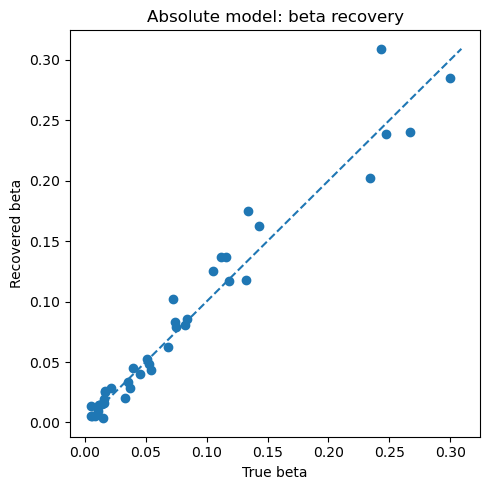

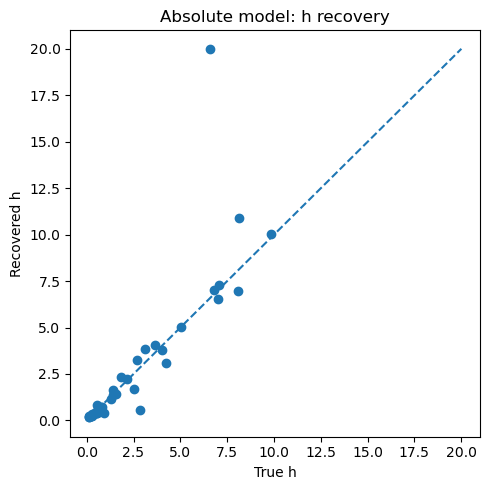

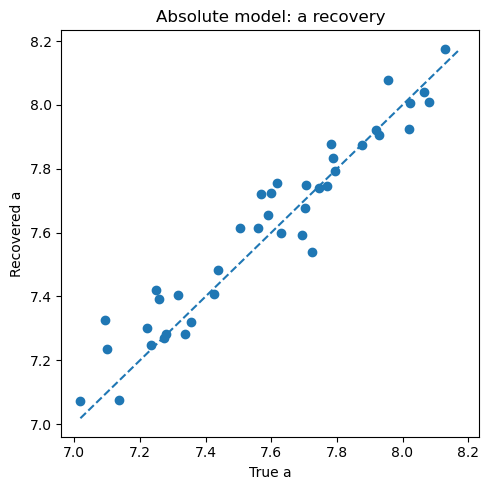

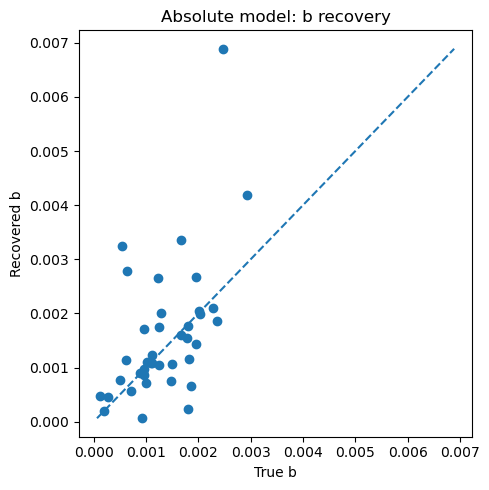

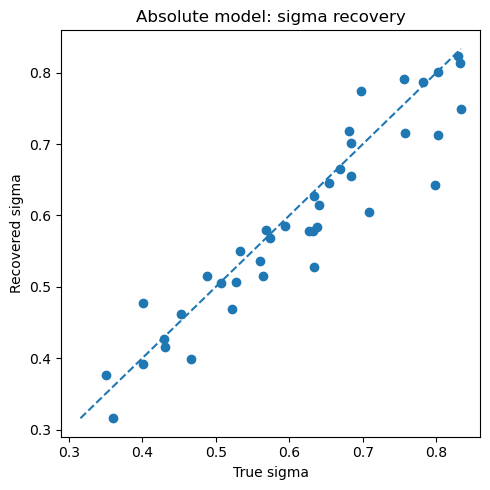

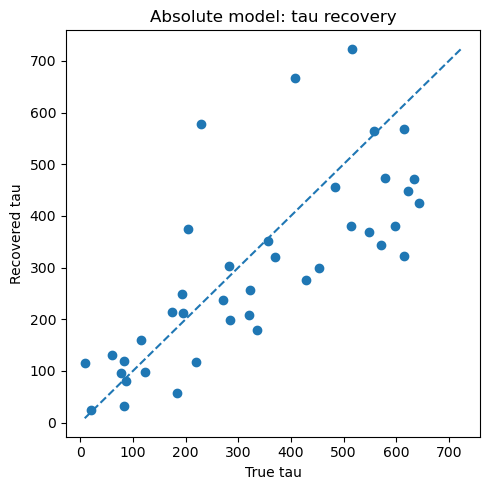

In [ ]:
for parameter, (true_col, recovered_col) in RECOVERY_COLUMNS.items():
    plot_parameter_recovery(
        abs_recovery_by_set,
        true_col,
        recovered_col,
        parameter,
        "Absolute model"
    )

## Squared RT recovery

In [ ]:
SQD_RECOVERY_RANGES = {
    "beta": (0.005, 0.35),
    "h": (0.1, 12.0),
    "a": (7.0, 8.2),
    "b": (0.0, 0.0001),
    "sigma": (0.35, 0.85),
    "tau": (0.0, 650.0)
}

sqd_true_parameter_sets = sample_full_true_parameters(N_RECOVERY_SETS, SQD_RECOVERY_RANGES)

In [ ]:
sqd_recovery = run_full_model_recovery(
    recovery_template,
    sqd_true_parameter_sets,
    N_RECOVERY_REPETITIONS,
    fit_squared,
    "squared"
)
print(f"Successful recovery runs: {len(sqd_recovery)} / {N_RECOVERY_SETS * N_RECOVERY_REPETITIONS}")

Successful recovery runs: 120 / 120


In [ ]:
sqd_recovery_metrics, sqd_recovery_by_set = summarize_recovery_metrics(sqd_recovery)
sqd_recovery_metrics

,bias,rmse,correlation,p_value,parameter
0,0.011154,0.029808,0.984831,1.622677e-30,beta
1,0.345814,2.295994,0.975838,1.042577e-26,h
2,0.013820,0.107562,0.950797,6.192708e-21,a
3,-0.000005,0.000055,0.527933,4.633922e-04,b
4,0.011316,0.114130,0.727407,1.055586e-07,sigma
5,-110.699749,204.340258,0.593188,5.487520e-05,tau


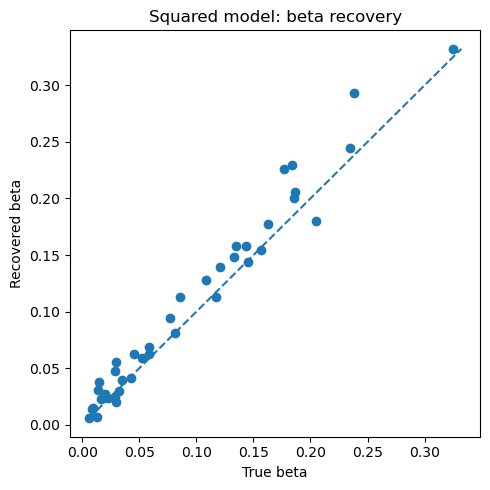

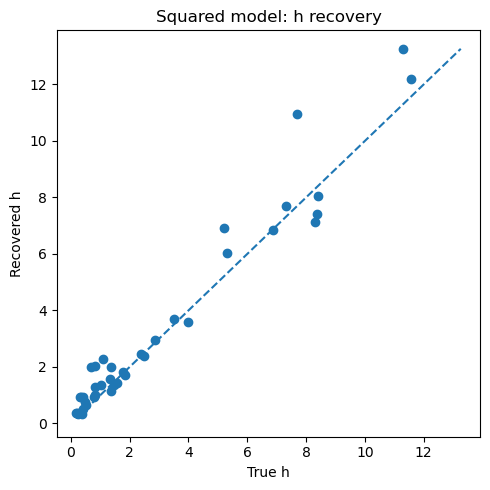

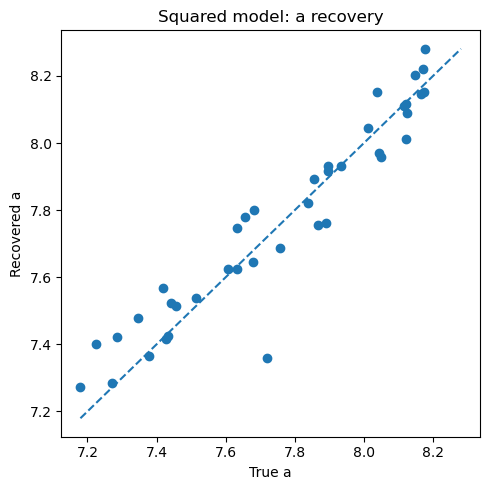

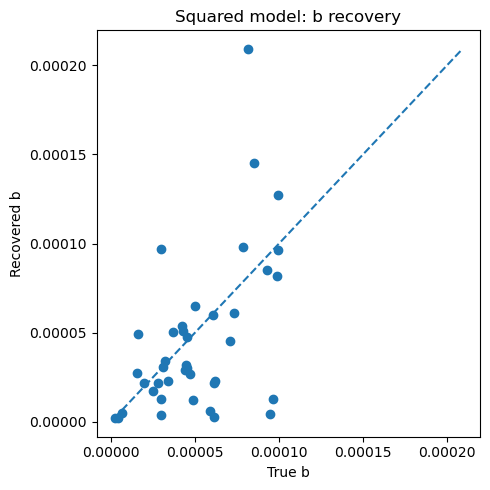

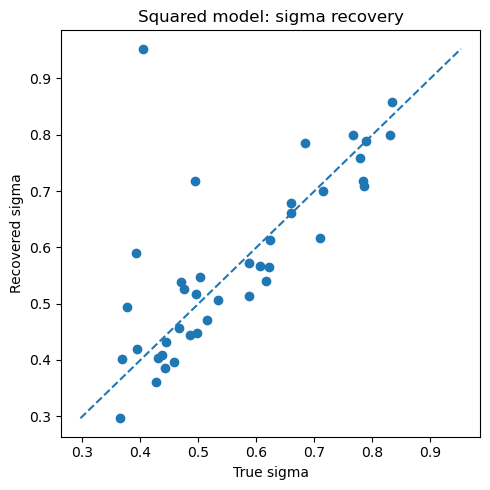

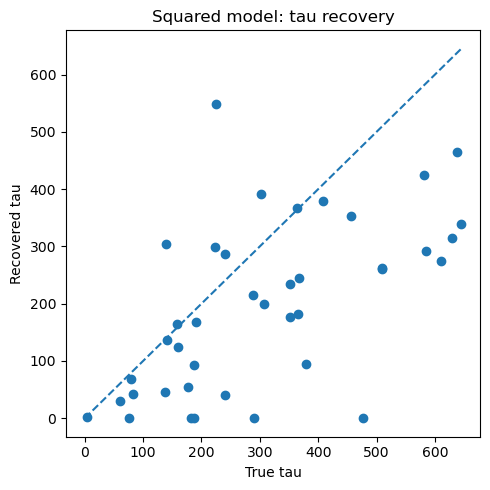

In [ ]:
for parameter, (true_col, recovered_col) in RECOVERY_COLUMNS.items():
    plot_parameter_recovery(
        sqd_recovery_by_set,
        true_col,
        recovered_col,
        parameter,
        "Squared model"
    )

## Exponential RT recovery

In [ ]:
EXP_RECOVERY_RANGES = {
    "beta": (0.005, 0.35),
    "h": (0.1, 12.0),
    "a": (6.9, 8.2),
    "b": (0.0, 0.35),
    "sigma": (0.35, 0.85),
    "tau": (0.0, 650.0)
}

exp_true_parameter_sets = sample_full_true_parameters(N_RECOVERY_SETS, EXP_RECOVERY_RANGES)

In [ ]:
exp_recovery = run_full_model_recovery(
    recovery_template,
    exp_true_parameter_sets,
    N_RECOVERY_REPETITIONS,
    fit_exponential,
    "exponential"
)
print(f"Successful recovery runs: {len(exp_recovery)} / {N_RECOVERY_SETS * N_RECOVERY_REPETITIONS}")

Successful recovery runs: 120 / 120


In [ ]:
exp_recovery_metrics, exp_recovery_by_set = summarize_recovery_metrics(exp_recovery)
exp_recovery_metrics

,bias,rmse,correlation,p_value,parameter
0,0.008216,0.043128,0.976992,4.156293e-27,beta
1,32.081717,352.997650,0.504582,8.996319e-04,h
2,0.026353,0.102920,0.979731,3.827851e-28,a
3,0.015742,0.124987,0.740844,4.602939e-08,b
4,-0.021818,0.058801,0.963749,2.089822e-23,sigma
5,-33.768717,156.498397,0.861367,9.830308e-13,tau


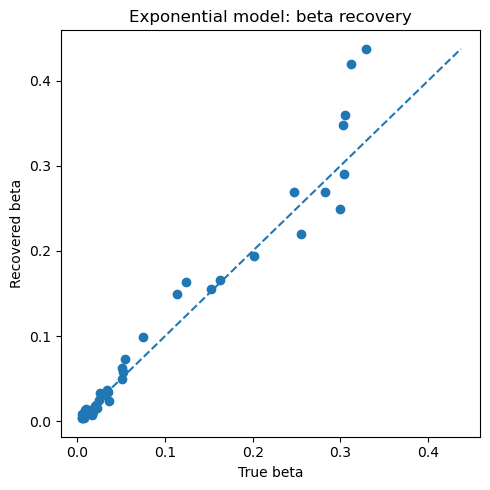

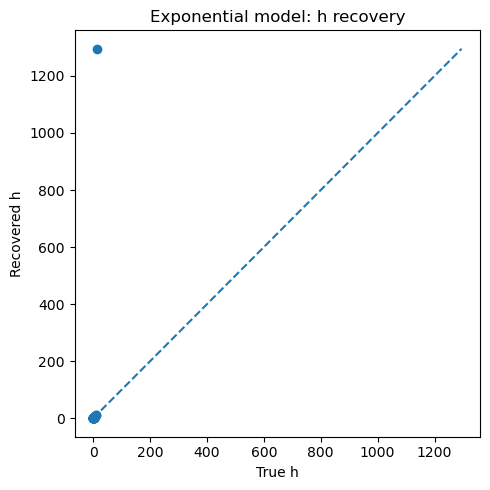

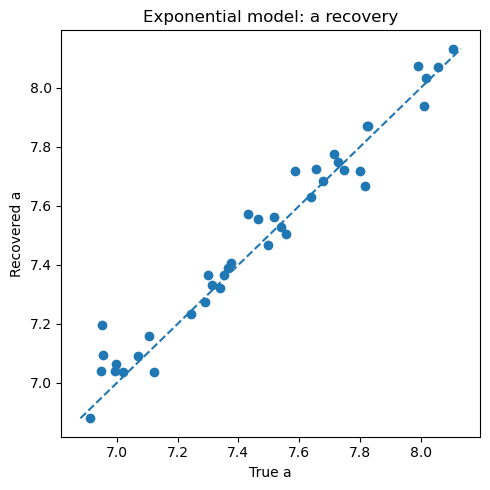

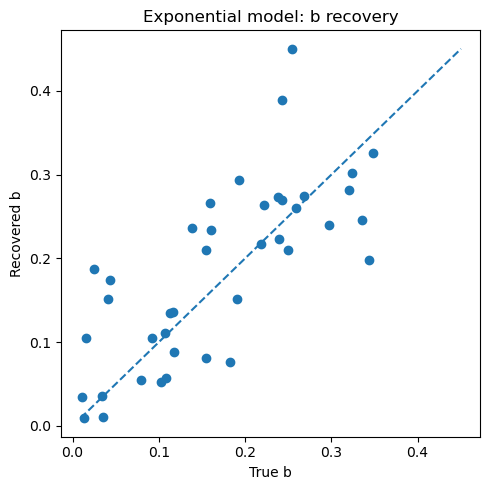

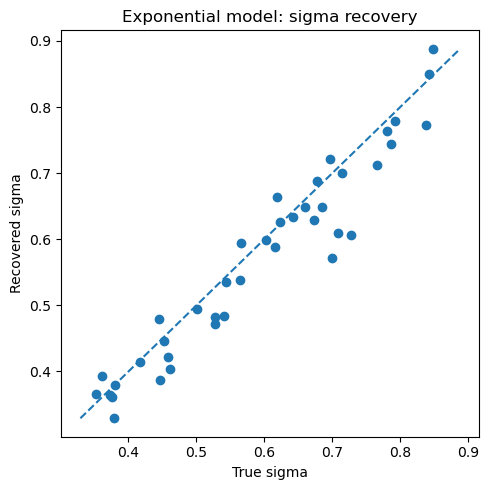

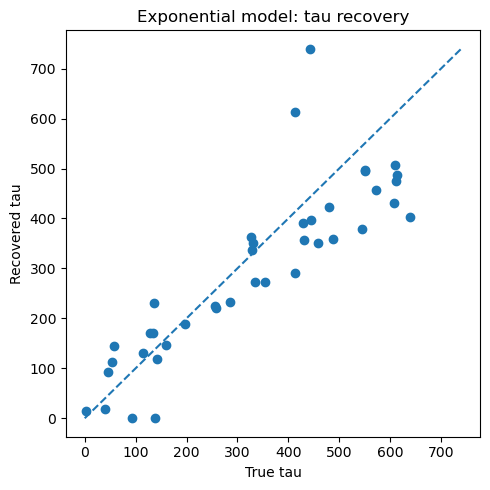

In [ ]:
for parameter, (true_col, recovered_col) in RECOVERY_COLUMNS.items():
    plot_parameter_recovery(
        exp_recovery_by_set,
        true_col,
        recovered_col,
        parameter,
        "Exponential model"
    )

## Does RT improve identifiability?

The same simulated choices are fitted once with the full chocie + RT model and once with the choice-only baseline. The comparison is restricted to the shared parameters beta and h.

In [ ]:
abs_choice_vs_full = compare_choice_and_full_recovery(abs_recovery)
abs_choice_vs_full["model"] = "absolute"

sqd_choice_vs_full = compare_choice_and_full_recovery(sqd_recovery)
sqd_choice_vs_full["model"] = "squared"

exp_choice_vs_full = compare_choice_and_full_recovery(exp_recovery)
exp_choice_vs_full["model"] = "exponential"

choice_vs_full_recovery = pd.concat([
    abs_choice_vs_full, sqd_choice_vs_full, exp_choice_vs_full], ignore_index=True)

choice_vs_full_recovery[["model", "parameter", "full_rmse", "choice_rmse", "full_mae", "choice_mae"]]

,model,parameter,full_rmse,choice_rmse,full_mae,choice_mae
0,absolute,beta,0.028672,0.028486,0.018091,0.018316
1,absolute,h,4.269225,8.675329,1.030483,1.447633
2,squared,beta,0.029808,0.027264,0.020394,0.017496
3,squared,h,2.295994,455.225888,0.953249,42.414331
4,exponential,beta,0.043128,0.043516,0.023988,0.024335
5,exponential,h,352.997650,175.961451,32.843902,16.858804


# 8. Test-Retest Reliability

## Independent Run B fits

In [ ]:
def fit_model_run_b(fit_function, parameter_names, model_name):
    """Fit one model independently to Run B for all participants."""

    results = []

    for i, file in enumerate(mat_files):
        participant = sio.loadmat(file)
        data_run_b = participant[RUN_B_KEY]

        # Fit the model to Run B
        best_result, all_results = fit_function(data_run_b)

        # Count valid optimization starts
        n_successful = sum(
            is_valid_optimization_result(result)
            for result in all_results
        )

        row = {
            "participant": file.stem,
            "model": model_name,
            "fit_success": best_result is not None,
            "successful_starts": n_successful,
            "total_starts": len(all_results)
        }

        # Store parameter estimates if fitting succeeded
        if best_result is not None:
            row["nll"] = best_result.fun

            for name, value in zip(parameter_names, best_result.x):
                row[name] = value

        results.append(row)

        print(f"[{i + 1}/{len(mat_files)}] {model_name} Run B: {file.stem}")

    return pd.DataFrame(results)

In [ ]:
# Run choice-only model
run_b_choice = fit_model_run_b(
    fit_choice_only, 
    CHOICE_PARAMETERS, 
    "choice_only"
)

[1/49] choice_only Run B: 2rrjzhgj9
[2/49] choice_only Run B: 3lmzwis6r
[3/49] choice_only Run B: 4f8msviwg
[4/49] choice_only Run B: 52b64k0rp
[5/49] choice_only Run B: 5wlmihb4c
[6/49] choice_only Run B: 6owg3par9
[7/49] choice_only Run B: 8py7pm5i0
[8/49] choice_only Run B: 95vrrzevd
[9/49] choice_only Run B: bh348lli7
[10/49] choice_only Run B: c0ry57ax9
[11/49] choice_only Run B: ck5f3lx8c
[12/49] choice_only Run B: ctdyczfpw
[13/49] choice_only Run B: dasemqdsv
[14/49] choice_only Run B: derouhkrw
[15/49] choice_only Run B: dm8t9csqy
[16/49] choice_only Run B: eqi6zanpf
[17/49] choice_only Run B: etxmnk1pg
[18/49] choice_only Run B: goz8d3fp9
[19/49] choice_only Run B: hrqn8w6vu
[20/49] choice_only Run B: ig1j8ozi9
[21/49] choice_only Run B: iogaivfgt
[22/49] choice_only Run B: ir0t9ca41
[23/49] choice_only Run B: jtf46arcd
[24/49] choice_only Run B: kimjztxjq
[25/49] choice_only Run B: kqi5vqk0e
[26/49] choice_only Run B: ljm2sl8s0
[27/49] choice_only Run B: mu73zwng6
[28/49] ch

In [ ]:
# Run absolute RT model
run_b_absolute = fit_model_run_b(
    fit_absolute, 
    FULL_PARAMETERS, 
    "absolute"
)

[1/49] absolute Run B: 2rrjzhgj9
[2/49] absolute Run B: 3lmzwis6r
[3/49] absolute Run B: 4f8msviwg
[4/49] absolute Run B: 52b64k0rp
[5/49] absolute Run B: 5wlmihb4c
[6/49] absolute Run B: 6owg3par9
[7/49] absolute Run B: 8py7pm5i0
[8/49] absolute Run B: 95vrrzevd
[9/49] absolute Run B: bh348lli7
[10/49] absolute Run B: c0ry57ax9
[11/49] absolute Run B: ck5f3lx8c
[12/49] absolute Run B: ctdyczfpw
[13/49] absolute Run B: dasemqdsv
[14/49] absolute Run B: derouhkrw
[15/49] absolute Run B: dm8t9csqy
[16/49] absolute Run B: eqi6zanpf
[17/49] absolute Run B: etxmnk1pg
[18/49] absolute Run B: goz8d3fp9
[19/49] absolute Run B: hrqn8w6vu
[20/49] absolute Run B: ig1j8ozi9
[21/49] absolute Run B: iogaivfgt
[22/49] absolute Run B: ir0t9ca41
[23/49] absolute Run B: jtf46arcd
[24/49] absolute Run B: kimjztxjq
[25/49] absolute Run B: kqi5vqk0e
[26/49] absolute Run B: ljm2sl8s0
[27/49] absolute Run B: mu73zwng6
[28/49] absolute Run B: n08qsd76x
[29/49] absolute Run B: nvbinkqjq
[30/49] absolute Run B:

In [ ]:
# Run squared RT model
run_b_squared = fit_model_run_b(
    fit_squared, 
    FULL_PARAMETERS, 
    "squared"
)

[1/49] squared Run B: 2rrjzhgj9
[2/49] squared Run B: 3lmzwis6r
[3/49] squared Run B: 4f8msviwg
[4/49] squared Run B: 52b64k0rp
[5/49] squared Run B: 5wlmihb4c
[6/49] squared Run B: 6owg3par9
[7/49] squared Run B: 8py7pm5i0
[8/49] squared Run B: 95vrrzevd
[9/49] squared Run B: bh348lli7
[10/49] squared Run B: c0ry57ax9
[11/49] squared Run B: ck5f3lx8c
[12/49] squared Run B: ctdyczfpw
[13/49] squared Run B: dasemqdsv
[14/49] squared Run B: derouhkrw
[15/49] squared Run B: dm8t9csqy
[16/49] squared Run B: eqi6zanpf
[17/49] squared Run B: etxmnk1pg
[18/49] squared Run B: goz8d3fp9
[19/49] squared Run B: hrqn8w6vu
[20/49] squared Run B: ig1j8ozi9
[21/49] squared Run B: iogaivfgt
[22/49] squared Run B: ir0t9ca41
[23/49] squared Run B: jtf46arcd
[24/49] squared Run B: kimjztxjq
[25/49] squared Run B: kqi5vqk0e
[26/49] squared Run B: ljm2sl8s0
[27/49] squared Run B: mu73zwng6
[28/49] squared Run B: n08qsd76x
[29/49] squared Run B: nvbinkqjq
[30/49] squared Run B: o7piq7dwr
[31/49] squared Run

In [ ]:
# Run exponential RT model
run_b_exponential = fit_model_run_b(
    fit_exponential, 
    FULL_PARAMETERS, 
    "exponential"
)

[1/49] exponential Run B: 2rrjzhgj9
[2/49] exponential Run B: 3lmzwis6r
[3/49] exponential Run B: 4f8msviwg
[4/49] exponential Run B: 52b64k0rp
[5/49] exponential Run B: 5wlmihb4c
[6/49] exponential Run B: 6owg3par9
[7/49] exponential Run B: 8py7pm5i0
[8/49] exponential Run B: 95vrrzevd
[9/49] exponential Run B: bh348lli7
[10/49] exponential Run B: c0ry57ax9
[11/49] exponential Run B: ck5f3lx8c
[12/49] exponential Run B: ctdyczfpw
[13/49] exponential Run B: dasemqdsv
[14/49] exponential Run B: derouhkrw
[15/49] exponential Run B: dm8t9csqy
[16/49] exponential Run B: eqi6zanpf
[17/49] exponential Run B: etxmnk1pg
[18/49] exponential Run B: goz8d3fp9
[19/49] exponential Run B: hrqn8w6vu
[20/49] exponential Run B: ig1j8ozi9
[21/49] exponential Run B: iogaivfgt
[22/49] exponential Run B: ir0t9ca41
[23/49] exponential Run B: jtf46arcd
[24/49] exponential Run B: kimjztxjq
[25/49] exponential Run B: kqi5vqk0e
[26/49] exponential Run B: ljm2sl8s0
[27/49] exponential Run B: mu73zwng6
[28/49] ex

In [ ]:
print(f"Choice-only Run B: {run_b_choice['fit_success'].sum()} / {len(run_b_choice)}")
print(f"Absolute Run B: {run_b_absolute['fit_success'].sum()} / {len(run_b_absolute)}")
print(f"Squared Run B: {run_b_squared['fit_success'].sum()} / {len(run_b_squared)}")
print(f"Exponential Run B: {run_b_exponential['fit_success'].sum()} / {len(run_b_exponential)}")

Choice-only Run B: 49 / 49
Absolute Run B: 49 / 49
Squared Run B: 49 / 49
Exponential Run B: 49 / 49


## Test-Retest reliability

In [ ]:
def compute_test_retest_reliability(run_a, run_b, parameter_names, model_name):
    """Compute Run A vs Run B parameter reliability across participants."""
    merged = run_a.merge(run_b, on="participant", suffixes=("_a", "_b"))

    reliability_results = []
    for parameter in parameter_names:
        a = merged[f"{parameter}_a"]
        b = merged[f"{parameter}_b"]

        valid = np.isfinite(a) & np.isfinite(b)

        r, p = pearsonr(a[valid], b[valid])

        reliability_results.append({
            "model": model_name,
            "parameter": parameter,
            "n": valid.sum(),
            "correlation": r,
            "p_value": p
        })

    return pd.DataFrame(reliability_results), merged

In [ ]:
# Choice-only reliability
choice_reliability, choice_ab = compute_test_retest_reliability(run_a_choice, run_b_choice, CHOICE_PARAMETERS, "choice_only")
choice_reliability

,model,parameter,n,correlation,p_value
0,choice_only,beta,49,0.824633,3.263315e-13
1,choice_only,h,49,-0.037775,7.966440e-01


In [ ]:
# Absolute reliability
abs_reliability, abs_ab = compute_test_retest_reliability(run_a_absolute, run_b_absolute, FULL_PARAMETERS, "absolute")
abs_reliability

,model,parameter,n,correlation,p_value
0,absolute,beta,49,0.828178,2.105094e-13
1,absolute,h,49,0.033856,8.173624e-01
2,absolute,a,49,0.777853,4.849237e-11
3,absolute,b,49,0.049720,7.344089e-01
4,absolute,sigma,49,0.497612,2.749364e-04
5,absolute,tau,49,0.438093,1.642358e-03


In [ ]:
# Squared reliability
sqd_reliability, sqd_ab = compute_test_retest_reliability(run_a_squared, run_b_squared, FULL_PARAMETERS, "squared")
sqd_reliability

,model,parameter,n,correlation,p_value
0,squared,beta,49,0.826586,2.566282e-13
1,squared,h,49,-0.037444,7.983915e-01
2,squared,a,49,0.760004,2.403536e-10
3,squared,b,49,-0.052245,7.214525e-01
4,squared,sigma,49,0.490509,3.462671e-04
5,squared,tau,49,0.347890,1.430915e-02


In [ ]:
# Exponential reliability
exp_reliability, exp_ab = compute_test_retest_reliability(run_a_exponential, run_b_exponential, FULL_PARAMETERS, "exponential")
exp_reliability

,model,parameter,n,correlation,p_value
0,exponential,beta,49,0.825048,3.101717e-13
1,exponential,h,49,0.060165,6.813247e-01
2,exponential,a,49,0.774403,6.682782e-11
3,exponential,b,49,0.420009,2.660521e-03
4,exponential,sigma,49,0.707349,1.331311e-08
5,exponential,tau,49,0.469748,6.608461e-04


## Reliability plots

In [ ]:
def plot_test_retest_reliability(merged_data, parameter, model_name):
    """Plot Run A vs Run B parameter estimates."""
    x = merged_data[f"{parameter}_a"]
    y = merged_data[f"{parameter}_b"]

    valid = np.isfinite(x) & np.isfinite(y)

    plt.figure(figsize=(5, 5))
    plt.scatter(x[valid], y[valid])

    limits = [min(x[valid].min(), y[valid].min()),
              max(x[valid].max(), y[valid].max())]

    plt.plot(limits, limits, "--")
    plt.xlabel(f"Run A {parameter}")
    plt.ylabel(f"Run B {parameter}")
    plt.title(f"{model_name}: {parameter} reliability")
    plt.tight_layout()
    plt.show()

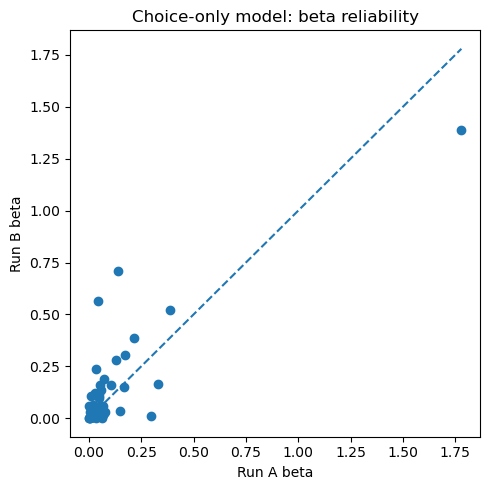

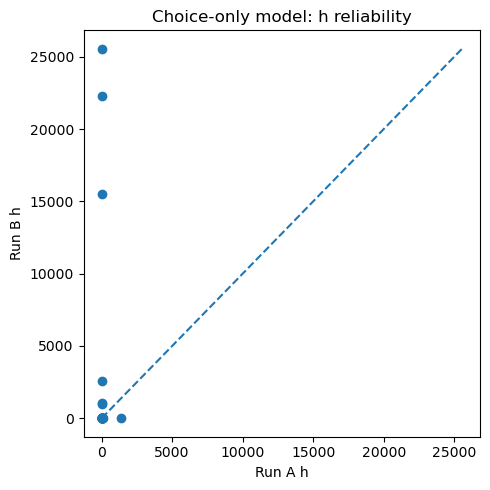

In [ ]:
# Choice-only
for parameter in CHOICE_PARAMETERS:
    plot_test_retest_reliability(choice_ab, parameter, "Choice-only model")

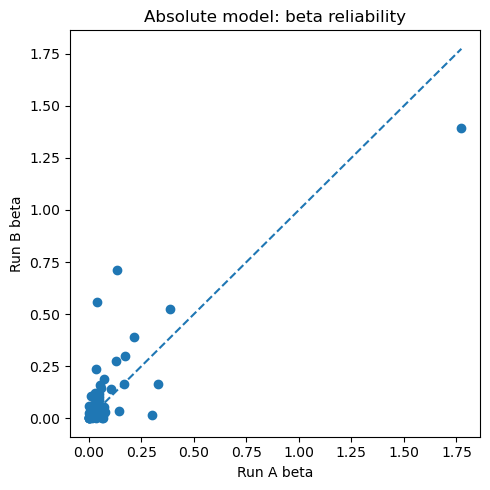

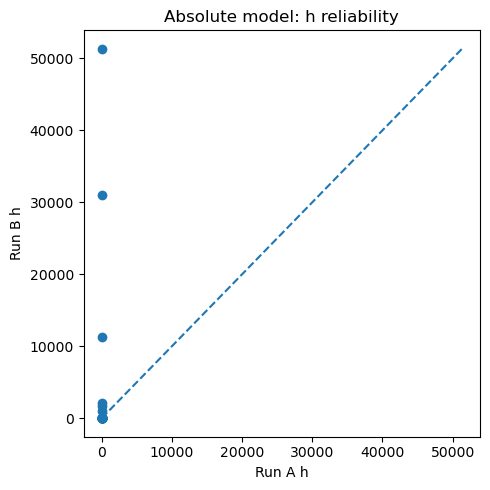

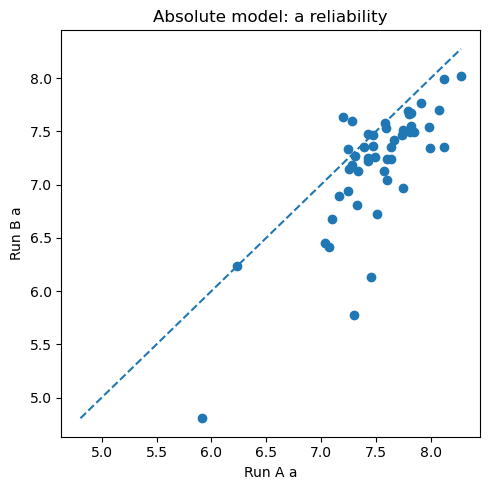

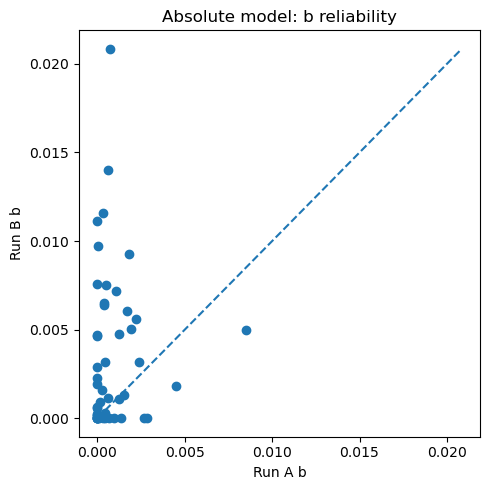

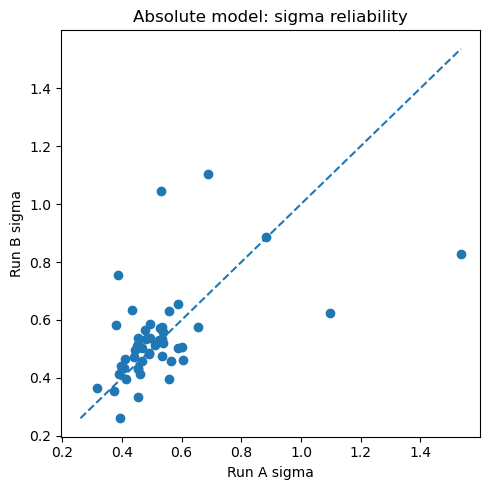

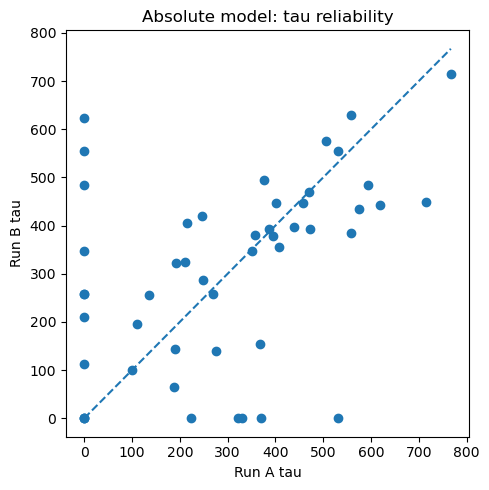

In [ ]:
# Absolute
for parameter in FULL_PARAMETERS:
    plot_test_retest_reliability(abs_ab, parameter, "Absolute model")

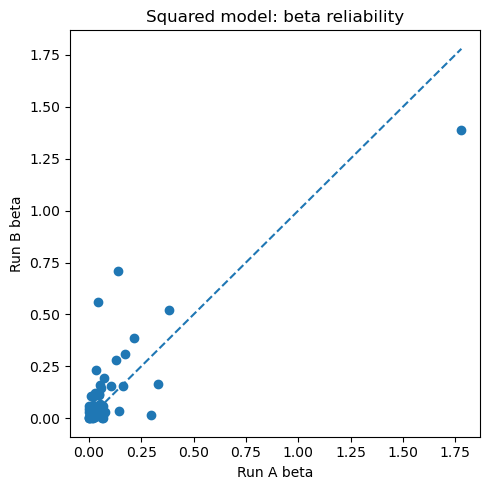

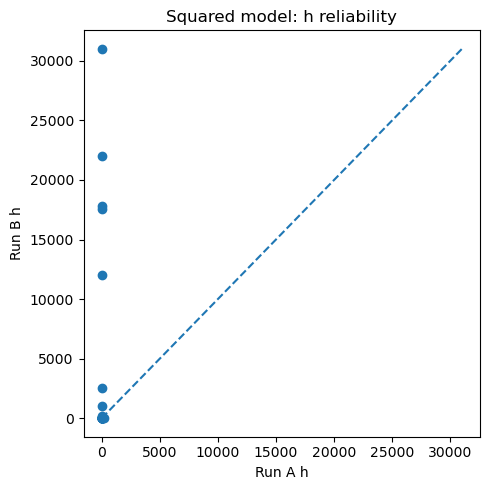

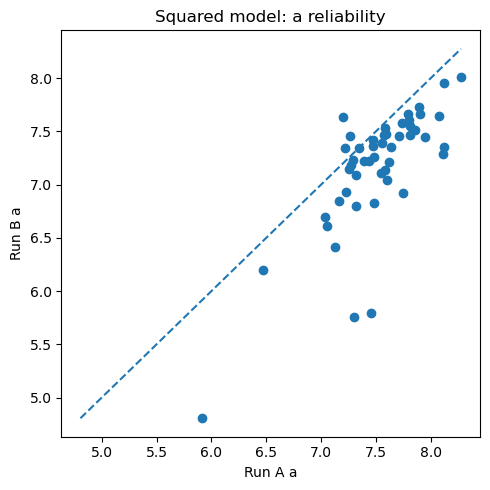

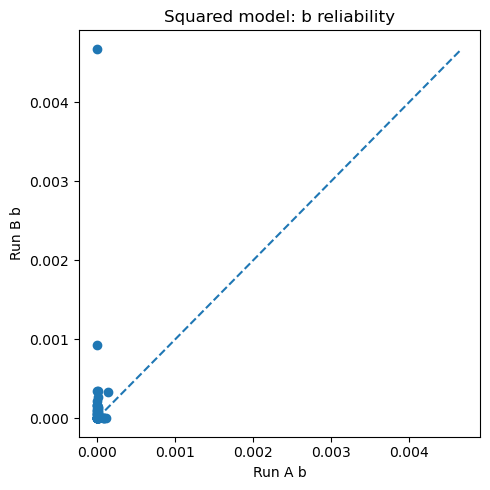

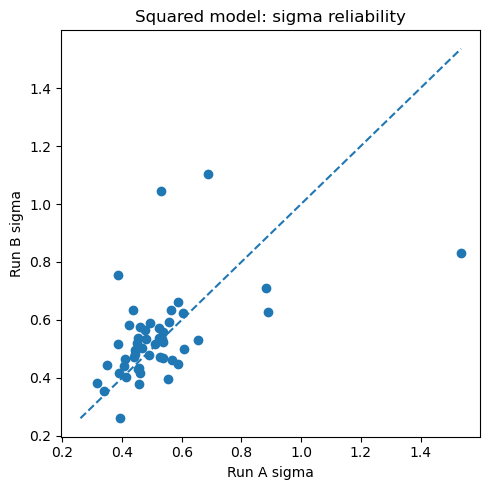

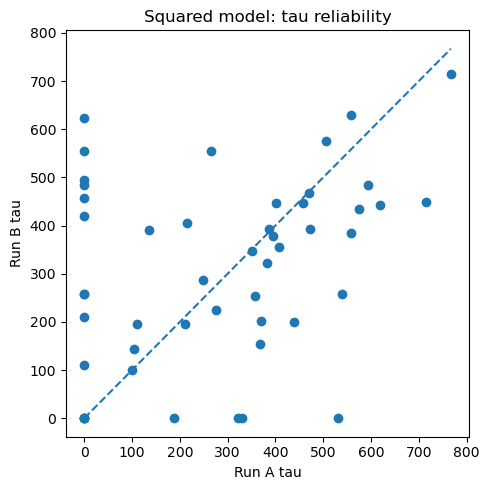

In [ ]:
# Squared
for parameter in FULL_PARAMETERS:
    plot_test_retest_reliability(sqd_ab, parameter, "Squared model")

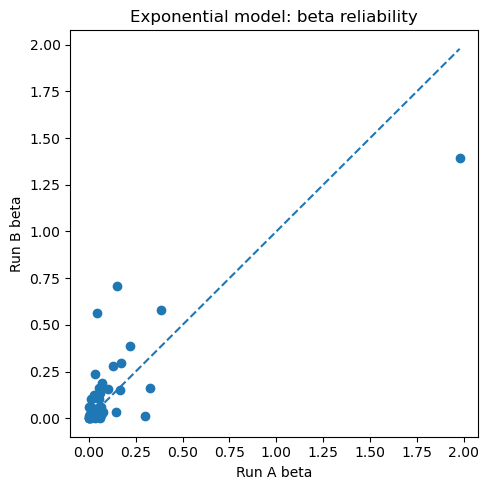

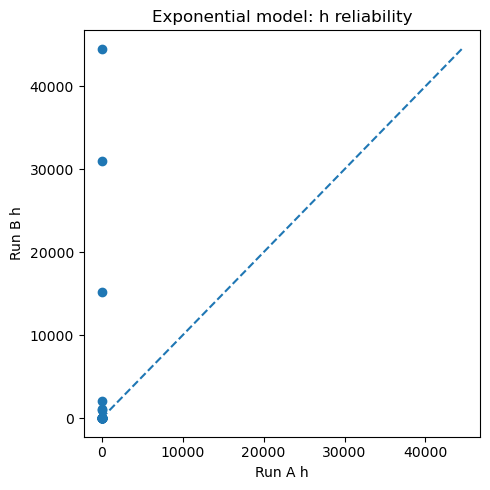

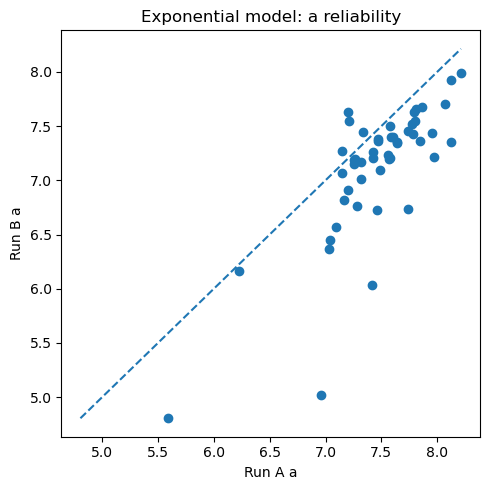

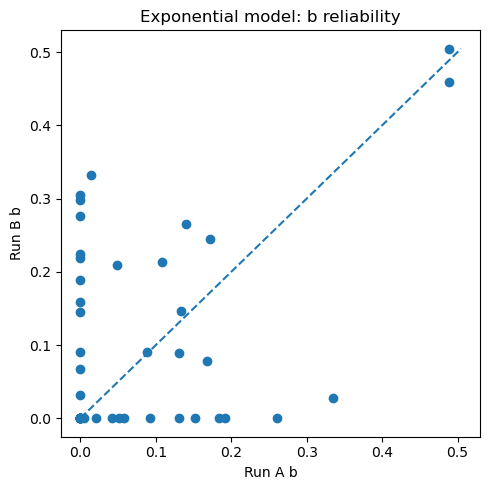

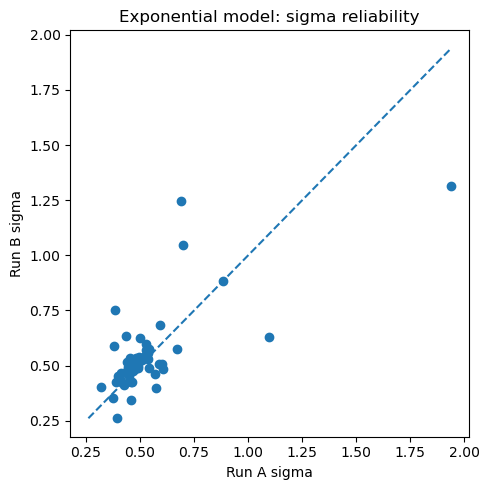

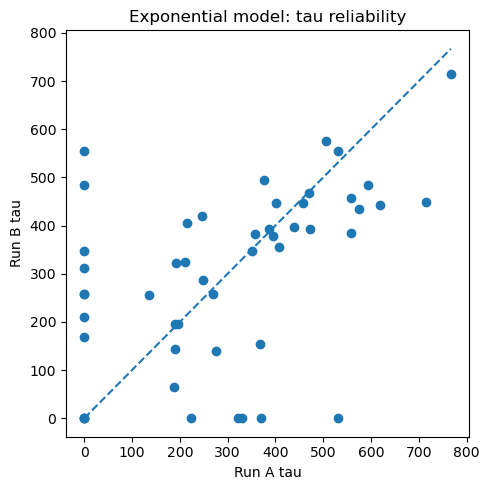

In [ ]:
# Exponential
for parameter in FULL_PARAMETERS:
    plot_test_retest_reliability(exp_ab, parameter, "Exponential model")

## Does RT improve reliability?

In [ ]:
reliability_comparison = (
    choice_reliability[["parameter", "correlation"]]
    .rename(columns={"correlation": "choice_only_r"})
    .merge(abs_reliability[["parameter", "correlation"]], on="parameter", how="inner")
    .rename(columns={"correlation": "absolute_r"})
    .merge(sqd_reliability[["parameter", "correlation"]], on="parameter", how="inner")
    .rename(columns={"correlation": "squared_r"})
    .merge(exp_reliability[["parameter", "correlation"]], on="parameter", how="inner")
    .rename(columns={"correlation": "exponential_r"})
)

for model_name in ["absolute", "squared", "exponential"]:
    reliability_comparison[f"{model_name}_difference"] = (reliability_comparison[f"{model_name}_r"] - reliability_comparison["choice_only_r"])

reliability_comparison

,parameter,choice_only_r,absolute_r,squared_r,exponential_r,absolute_difference,squared_difference,exponential_difference
0,beta,0.824633,0.828178,0.826586,0.825048,0.003545,0.001953,0.000415
1,h,-0.037775,0.033856,-0.037444,0.060165,0.071631,0.000332,0.097940


## Extreme-h diagnostic

In [ ]:
def summarize_extreme_h(run_results, model_name, threshold=100):
    """Summarize unusually large h estimates."""
    extreme = run_results[run_results["h"] > threshold]
    return {
        "model": model_name,
        "n_extreme_h": len(extreme),
        "max_h": run_results["h"].max()
    }

In [ ]:
extreme_h_summary = pd.DataFrame([
    summarize_extreme_h(run_b_choice, "choice_only"),
    summarize_extreme_h(run_b_absolute, "absolute"),
    summarize_extreme_h(run_b_squared, "squared"),
    summarize_extreme_h(run_b_exponential, "exponential")    
])
extreme_h_summary

,model,n_extreme_h,max_h
0,choice_only,6,25548.206342
1,absolute,7,51329.497432
2,squared,8,31010.071578
3,exponential,6,44511.907977


# 9. Out-of-Sample Prediction

## Shared predictive utilities

In [ ]:
CONDITION_LABELS = {
    1.0: "reward",
    2.0: "loss"
}

In [ ]:
def choice_log_likelihood_per_trial(y, pi):
    """Compute Bernoulli choice log-likelihood for each trial."""
    eps = 1e-12
    pi = np.clip(pi, eps, 1 - eps)
    return (y * np.log(pi) + (1 - y) * np.log(1 - pi))

In [ ]:
def evaluate_choice_prediction(data, beta, h):
    """Evaluate held-out choice prediction for one participant."""
    r_cert, r_uncert, p, y, _, condition = prepare_data(data)
    v_cert, v_uncert = compute_subjective_values(r_cert, r_uncert, p, h)

    delta_v = compute_value_difference(v_cert, v_uncert)
    pi = compute_choice_probability(delta_v, beta)
    
    trial_ll = choice_log_likelihood_per_trial(y, pi)

    prediction = (pi >= 0.5).astype(int)
    correct = (prediction == y).astype(float)

    return pd.DataFrame({
        "choice_ll": trial_ll,
        "choice_correct": correct,
        "condition": condition
    })

In [ ]:
def evaluate_choice_oos_all(fit_results, model_name):
    """Evaluate Run A choice parameters on Run B for all participants."""
    trial_results = []
    for file in mat_files:
        participant_id = file.stem
        participant = sio.loadmat(file)
        data_run_b = participant[RUN_B_KEY]

        row = fit_results.loc[fit_results["participant"] == participant_id].iloc[0]
        
        participant_results = evaluate_choice_prediction(data_run_b, row["beta"], row["h"])
        participant_results["participant"] = participant_id
        participant_results["model"] = model_name

        trial_results.append(participant_results)

    return pd.concat(trial_results, ignore_index=True)

In [ ]:
def summarize_choice_oos(trial_results):
    """Summarize held-out choice performance by participant and condition."""
    summary = (
        trial_results
        .groupby(["participant", "model", "condition"], as_index=False)
        .agg(
            choice_ll=("choice_ll", "mean"), 
            choice_accuracy=("choice_correct", "mean"), 
            n_trials=("choice_ll", "size")
        )
    )

    summary["condition_label"] = summary["condition"].map(CONDITION_LABELS)

    return summary

In [ ]:
def compare_choice_oos_to_baseline(choice_summary, full_model, baseline_model="choice_only"):
    """Compare one full model with the choice-only baseline on Run B choices."""
    subset = choice_summary[choice_summary["model"].isin([baseline_model, full_model])]

    comparison = (subset.pivot(
        index=["participant", "condition_label"], 
        columns="model", 
        values=["choice_ll", "choice_accuracy"]
    ).reset_index())

    comparison.columns = [
        "_".join(str(x) for x in col if str(x) != "")
        if isinstance(col, tuple)
        else col
        for col in comparison.columns
    ]

    comparison["ll_difference"] = (
        comparison[f"choice_ll_{full_model}"]
        - comparison[f"choice_ll_{baseline_model}"]
    )

    comparison["accuracy_difference"] = (
            comparison[f"choice_accuracy_{full_model}"]
            - comparison[f"choice_accuracy_{baseline_model}"]
        )

    difference_summary = (
        comparison.groupby("condition_label")[["ll_difference", "accuracy_difference"]]
        .agg(["mean", "median", "std"])
    )

    test_rows = []

    for condition in ["reward", "loss"]:
        ll_diff = comparison.loc[comparison["condition_label"] == condition, "ll_difference"].dropna()

        statistic, p_value=wilcoxon(ll_diff)

        test_rows.append({
            "condition": condition,
            "n": len(ll_diff),
            "mean_difference": ll_diff.mean(),
            "median_difference": ll_diff.median(),
            "wilcoxon_statistic": statistic,
            "p_value": p_value
        })

    tests = pd.DataFrame(test_rows)
    
    return comparison, difference_summary, tests

In [ ]:
def shifted_lognormal_log_likelihood_per_trial(rt, mu, sigma, tau):
    """Compute shifted log-normal log-likelihood for each trial."""

    if sigma <= 0 or tau < 0:
        return np.full(len(rt), -np.inf)

    rt_shifted = rt - tau

    ll  = np.full(len(rt), -np.inf)
    valid = rt_shifted > 0

    log_rt = np.log(rt_shifted[valid])

    ll[valid] = (
        -np.log(rt_shifted[valid])
        -np.log(sigma)
        -0.5 * np.log(2 * np.pi)
        -((log_rt - mu[valid]) ** 2)
        / (2 * sigma ** 2)
    )

    return ll

In [ ]:
def expected_rt_shifted_lognormal(mu, sigma, tau):
    """Compute expected RT under the shifted log-normal model."""
    return tau + np.exp(mu + 0.5 * sigma ** 2)

In [ ]:
def compute_rt_mu(delta_v, a, b, model_name):
    """Compute trial-wise log-RT location for each RT model."""
    if model_name == "absolute":
        return a - b * np.abs(delta_v)
    elif model_name == "squared":
        return a - b * (delta_v ** 2)
    elif model_name == "exponential":
        return a + b * np.exp(-(delta_v ** 2))
    else:
        raise ValueError(f"Unknown RT model: {model_name}")

In [ ]:
def evaluate_rt_prediction(data, h, a, b, sigma, tau, model_name):
    """Evaluate held-out RT prediction for one participant."""
    r_cert, r_uncert, p, _, rt, condition = prepare_data(data)
    v_cert, v_uncert = compute_subjective_values(r_cert, r_uncert, p, h)
    
    delta_v = compute_value_difference(v_cert, v_uncert)
    mu = compute_rt_mu(delta_v, a, b, model_name)

    rt_ll = shifted_lognormal_log_likelihood_per_trial(rt, mu, sigma, tau)
    predicted_rt = expected_rt_shifted_lognormal(mu, sigma, tau)

    return pd.DataFrame({
        "rt": rt,
        "predicted_rt": predicted_rt,
        "rt_ll": rt_ll,
        "rt_absolute_error": np.abs(predicted_rt - rt),
        "condition": condition,
        "support_violation": rt <= tau
    })

In [ ]:
def evaluate_rt_oos_all(fit_results, model_name):
    """Evaluate Run A RT parameters on Run B for all participants."""
    trial_results = []
    for file in mat_files:
        participant_id = file.stem

        participant = sio.loadmat(file)
        data_run_b = participant[RUN_B_KEY]

        row = fit_results.loc[fit_results["participant"] == participant_id].iloc[0]
        participant_results = evaluate_rt_prediction(
            data_run_b, row["h"], row["a"], row["b"], row["sigma"], row["tau"], model_name
        )

        participant_results["participant"] = participant_id
        participant_results["model"] = model_name

        trial_results.append(participant_results)

    return pd.concat(trial_results, ignore_index=True)

In [ ]:
def summarize_rt_oos(trial_results):
    """Summarize held-out RT prediction by participant and condition."""
    summary = (
        trial_results
        .groupby(["participant", "model", "condition"], as_index=False)
        .agg(
            rt_mae=("rt_absolute_error", "mean"), 
            mean_rt=("rt", "mean"),
            mean_predicted_rt=("predicted_rt", "mean"), 
            n_trials=("rt", "size"),
            n_support_violations=("support_violation", "sum")
        )
    )
    summary["condition_label"] = (summary["condition"].map(CONDITION_LABELS))
    return summary

In [ ]:
def summarize_rt_oos_descriptive(rt_summary):
    """Summarize participant-level RT prediction by condition."""
    return (rt_summary.groupby("condition_label")
            .agg(rt_mae_mean=("rt_mae", "mean"),
                 rt_mae_median=("rt_mae", "median"),
                 rt_mae_std=("rt_mae", "std"),
                 mean_observed_rt=("mean_rt", "mean"),
                 mean_predicted_rt=("mean_predicted_rt", "mean"), 
                 support_violations=("n_support_violations", "sum")
                 )
            )

In [ ]:
def plot_oos_metric(summary, models, metric, ylabel, title):
    """Plot participant-level OOS performance by model and condition."""
    plot_data = []
    labels = []

    for condition in ["reward", "loss"]:
        for model in models:
            values = summary.loc[
                (summary["condition_label"] == condition)
                & (summary["model"] == model),
                metric
            ].dropna()

            plot_data.append(values)
            labels.append(f"{model}\n{condition}")

    plt.figure(figsize=(10, 5))
    plt.boxplot(plot_data, tick_labels=labels, showmeans=True)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

## Choice prediction on Run B

In [ ]:
choice_oos_choice_only = evaluate_choice_oos_all(run_a_choice, "choice_only")
choice_oos_absolute = evaluate_choice_oos_all(run_a_absolute, "absolute")
choice_oos_squared = evaluate_choice_oos_all(run_a_squared, "squared")
choice_oos_exponential = evaluate_choice_oos_all(run_a_exponential, "exponential")

choice_oos_summary = pd.concat([
    summarize_choice_oos(choice_oos_choice_only),
    summarize_choice_oos(choice_oos_absolute),
    summarize_choice_oos(choice_oos_squared),
    summarize_choice_oos(choice_oos_exponential)
], ignore_index=True)

choice_oos_descriptive = (
    choice_oos_summary.groupby(["model", "condition_label"])
    [["choice_ll", "choice_accuracy"]].agg(["mean", "std"])
)

choice_oos_descriptive

choice_ll           choice_accuracy          
                                 mean       std            mean       std
model       condition_label                                              
absolute    loss            -0.662524  0.064040        0.649091  0.144825
            reward          -0.746067  0.691410        0.648590  0.218822
choice_only loss            -0.670211  0.087862        0.633786  0.163146
            reward          -0.802301  0.769829        0.654304  0.223140
exponential loss            -0.668341  0.085314        0.649909  0.150082
            reward          -0.846016  0.927068        0.661651  0.220683
squared     loss            -0.662370  0.064562        0.637254  0.159312
            reward          -0.753712  0.701399        0.654712  0.213405

### Absolute vs choice-only

In [ ]:
(choice_oos_absolute_comparison, 
 choice_oos_absolute_difference, 
 choice_oos_absolute_tests
) = compare_choice_oos_to_baseline(choice_oos_summary, full_model="absolute")

display(choice_oos_absolute_difference)
display(choice_oos_absolute_tests)

ll_difference                         accuracy_difference  \
                         mean        median       std                mean   
condition_label                                                             
loss                 0.007687  5.871388e-07  0.055416            0.015304   
reward               0.056234 -1.856618e-06  0.352121           -0.005714   

                                  
                median       std  
condition_label                   
loss               0.0  0.110588  
reward             0.0  0.122950

,condition,n,mean_difference,median_difference,wilcoxon_statistic,p_value
0,reward,49,0.056234,-1.856618e-06,516.0,0.611493
1,loss,49,0.007687,5.871388e-07,479.0,0.368395


### Squared vs choice-only

In [ ]:
(choice_oos_squared_comparison, 
 choice_oos_squared_difference, 
 choice_oos_squared_tests
) = compare_choice_oos_to_baseline(choice_oos_summary, full_model="squared")

display(choice_oos_squared_difference)
display(choice_oos_squared_tests)

ll_difference                     accuracy_difference         \
                         mean    median       std                mean median   
condition_label                                                                
loss                 0.007841  0.000002  0.055337            0.003467    0.0   
reward               0.048588 -0.000001  0.350255            0.000408    0.0   

                           
                      std  
condition_label            
loss             0.070963  
reward           0.099141

,condition,n,mean_difference,median_difference,wilcoxon_statistic,p_value
0,reward,49,0.048588,-0.000001,503.0,0.518596
1,loss,49,0.007841,0.000002,458.0,0.261986


### Exponential vs choice-only

In [ ]:
(choice_oos_exponential_comparison, 
 choice_oos_exponential_difference, 
 choice_oos_exponential_tests
) = compare_choice_oos_to_baseline(choice_oos_summary, full_model="exponential")

display(choice_oos_exponential_difference)
display(choice_oos_exponential_tests)

ll_difference                         accuracy_difference  \
                         mean        median       std                mean   
condition_label                                                             
loss                 0.001871  4.961890e-08  0.011266            0.016122   
reward              -0.043715 -2.545337e-07  0.279969            0.007347   

                                  
                median       std  
condition_label                   
loss               0.0  0.083612  
reward             0.0  0.086380

,condition,n,mean_difference,median_difference,wilcoxon_statistic,p_value
0,reward,49,-0.043715,-2.545337e-07,429.0,0.153122
1,loss,49,0.001871,4.961890e-08,412.0,0.107728


### Choice OOS plot

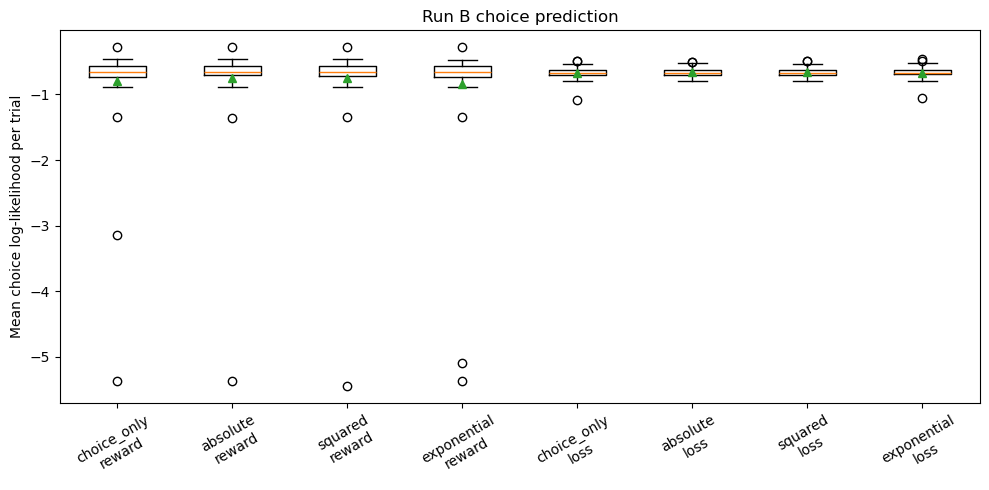

In [ ]:
plot_oos_metric(choice_oos_summary,
                models=["choice_only", "absolute", "squared", "exponential"],
                metric="choice_ll",
                ylabel="Mean choice log-likelihood per trial",
                title="Run B choice prediction")

## RT prediction on Run B

### Absolute

In [ ]:
rt_oos_absolute = evaluate_rt_oos_all(run_a_absolute, "absolute")
rt_oos_absolute_summary = summarize_rt_oos(rt_oos_absolute)
rt_oos_absolute_descriptive = summarize_rt_oos_descriptive(rt_oos_absolute_summary)
rt_oos_absolute_descriptive

,rt_mae_mean,rt_mae_median,rt_mae_std,mean_observed_rt,mean_predicted_rt,support_violations
condition_label,,,,,,
loss,1018.017982,898.685162,608.128939,2060.173486,2555.985510,2
reward,1050.719393,929.512501,623.328926,1854.191345,2509.760322,4


### Squared

In [ ]:
rt_oos_squared = evaluate_rt_oos_all(run_a_squared, "squared")
rt_oos_squared_summary = summarize_rt_oos(rt_oos_squared)
rt_oos_squared_descriptive = summarize_rt_oos_descriptive(rt_oos_squared_summary)
rt_oos_squared_descriptive

,rt_mae_mean,rt_mae_median,rt_mae_std,mean_observed_rt,mean_predicted_rt,support_violations
condition_label,,,,,,
loss,1015.889945,901.282344,607.154655,2060.173486,2539.796225,2
reward,1044.185542,917.161925,617.141713,1854.191345,2485.828992,5


### Exponential

In [ ]:
rt_oos_exponential = evaluate_rt_oos_all(run_a_exponential, "exponential")
rt_oos_exponential_summary = summarize_rt_oos(rt_oos_exponential)
rt_oos_exponential_descriptive = summarize_rt_oos_descriptive(rt_oos_exponential_summary)
rt_oos_exponential_descriptive

,rt_mae_mean,rt_mae_median,rt_mae_std,mean_observed_rt,mean_predicted_rt,support_violations
condition_label,,,,,,
loss,1058.050737,879.478548,920.439398,2060.173486,2598.029215,2
reward,1111.597294,912.974975,922.897049,1854.191345,2614.566417,4


### Support diagnostics

In [ ]:
rt_oos_summary = pd.concat([rt_oos_absolute_summary, rt_oos_squared_summary, rt_oos_exponential_summary],
                           ignore_index=True)
rt_oos_support = rt_oos_summary.loc[rt_oos_summary["n_support_violations"] > 0,
                                    ["model", "participant", "condition_label", "n_support_violations"]]
rt_oos_support

,model,participant,condition_label,n_support_violations
4,absolute,4f8msviwg,reward,1
80,absolute,ta33uq804,reward,3
81,absolute,ta33uq804,loss,2
102,squared,4f8msviwg,reward,1
142,squared,jtf46arcd,reward,1
178,squared,ta33uq804,reward,3
179,squared,ta33uq804,loss,2
200,exponential,4f8msviwg,reward,1
276,exponential,ta33uq804,reward,3
277,exponential,ta33uq804,loss,2


### RT OOS plot

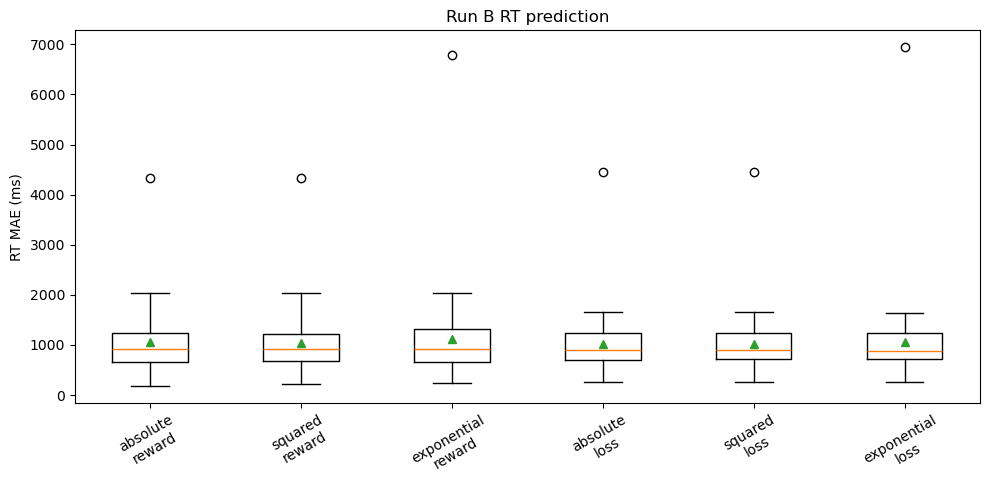

In [ ]:
plot_oos_metric(rt_oos_summary, 
                models=["absolute", "squared", "exponential"],
                metric="rt_mae", ylabel="RT MAE (ms)", title="Run B RT prediction")

# 10. Model Comparison & Value of RT

## RT Model Comparison

In [ ]:
rt_model_comparison_summary = (rt_oos_summary
                               .groupby(["model", "condition_label"])
                               .agg(
                                   mean_mae=("rt_mae", "mean"),
                                   median_mae=("rt_mae", "median"),
                                   std_mae=("rt_mae", "std"))
                                .reset_index())

rt_model_comparison_summary

,model,condition_label,mean_mae,median_mae,std_mae
0,absolute,loss,1018.017982,898.685162,608.128939
1,absolute,reward,1050.719393,929.512501,623.328926
2,exponential,loss,1058.050737,879.478548,920.439398
3,exponential,reward,1111.597294,912.974975,922.897049
4,squared,loss,1015.889945,901.282344,607.154655
5,squared,reward,1044.185542,917.161925,617.141713


In [ ]:
def compare_rt_models_friedman(rt_summary):
    """Compare RT MAE across the three models within each condition."""
    rows = []
    for condition in ["reward", "loss"]:
        condition_data = (rt_summary
            .loc[rt_summary["condition_label"] == condition,
                ["participant", "model", "rt_mae"]]
            .pivot(index="participant", columns="model", values="rt_mae")
            .dropna())

        statistic, p_value = friedmanchisquare(condition_data["absolute"], condition_data["squared"], condition_data["exponential"])

        rows.append({
            "condition": condition,
            "n": len(condition_data),
            "friedman_statistic": statistic,
            "p_value": p_value
        })

    return pd.DataFrame(rows)

In [ ]:
rt_model_friedman = compare_rt_models_friedman(rt_oos_summary)
rt_model_friedman

,condition,n,friedman_statistic,p_value
0,reward,49,1.265306,0.531181
1,loss,49,7.714286,0.021128


In [ ]:
def holm_adjust(p_values):
    """Apply Holm correction to a sequence of p-values."""
    p_values = np.asarray(p_values, dtype=float)

    order = np.argsort(p_values)
    adjusted = np.empty_like(p_values)

    running_max = 0.0
    m = len(p_values)

    for rank, index in enumerate(order):
        adjusted_p = (m - rank) * p_values[index]
        running_max = max(running_max, adjusted_p)
        adjusted[index] = min(running_max, 1.0)

    return adjusted

In [ ]:
def compare_rt_models_pairwise(rt_summary):
    """Pairwise participant-level Wilcoxon tests for RT MAE."""
    model_pairs = [("absolute", "squared"), ("absolute", "exponential"), ("squared", "exponential")]

    rows = []
    for condition in ["reward", "loss"]:
        condition_data = (
            rt_summary.loc[
                rt_summary["condition_label"] == condition,
                ["participant", "model", "rt_mae"]]
            .pivot(index="participant", columns="model", values="rt_mae")
            .dropna()
        )

        condition_rows = []
        for model_a, model_b in model_pairs:
            difference = condition_data[model_a] - condition_data[model_b]
            statistic, p_value = wilcoxon(difference)

            condition_rows.append({
                "condition": condition,
                "model_a": model_a,
                "model_b": model_b,
                "n": len(difference),
                "mean_difference": difference.mean(),
                "median_difference": difference.median(),
                "wilcoxon_statistic": statistic,
                "p_value": p_value
            })

        raw_p_values = [row["p_value"] for row in condition_rows]
        adjusted_p_values = holm_adjust(raw_p_values)

        for row, adjusted_p in zip(condition_rows, adjusted_p_values):
            row["p_holm"] = adjusted_p

        rows.extend(condition_rows)

    return pd.DataFrame(rows)

In [ ]:
rt_model_pairwise_tests = compare_rt_models_pairwise(rt_oos_summary)
rt_model_pairwise_tests

,condition,model_a,model_b,n,mean_difference,median_difference,wilcoxon_statistic,p_value,p_holm
0,reward,absolute,squared,49,6.533852,0.011647,547.0,0.521218,0.803525
1,reward,absolute,exponential,49,-60.877901,0.018288,505.0,0.289950,0.803525
2,reward,squared,exponential,49,-67.411753,0.698143,500.0,0.267842,0.803525
3,loss,absolute,squared,49,2.128037,0.474820,392.0,0.027738,0.083214
4,loss,absolute,exponential,49,-40.032755,0.076497,404.0,0.037757,0.083214
5,loss,squared,exponential,49,-42.160792,0.121368,482.0,0.197809,0.197809


In [ ]:
def summarize_pairwise_rt_differences(rt_summary):
    """Summarize participant-level pairwise RT MAE differences."""
    model_pairs = [("absolute", "squared"), ("absolute", "exponential"), ("squared", "exponential")]

    rows = []
    for condition in ["reward", "loss"]:
        condition_data = (
            rt_summary.loc[
                rt_summary["condition_label"] == condition,
                ["participant", "model", "rt_mae"]]
            .pivot(index="participant", columns="model", values="rt_mae")
            .dropna()
        )

        for model_a, model_b in model_pairs:
            difference = condition_data[model_a] - condition_data[model_b]

            rows.append({
                "condition": condition,
                "model_a": model_a,
                "model_b": model_b,
                "mean_difference": difference.mean(),
                "median_difference": difference.median(),
                "model_a_better_n": (difference < 0).sum(),
                "model_b_better_n": (difference > 0).sum(),
                "ties_n": (difference == 0).sum()
            })

    return pd.DataFrame(rows)

In [ ]:
rt_pairwise_difference_summary = (summarize_pairwise_rt_differences(rt_oos_summary))
rt_pairwise_difference_summary

,condition,model_a,model_b,mean_difference,median_difference,model_a_better_n,model_b_better_n,ties_n
0,reward,absolute,squared,6.533852,0.011647,22,27,0
1,reward,absolute,exponential,-60.877901,0.018288,22,27,0
2,reward,squared,exponential,-67.411753,0.698143,21,28,0
3,loss,absolute,squared,2.128037,0.474820,17,32,0
4,loss,absolute,exponential,-40.032755,0.076497,17,32,0
5,loss,squared,exponential,-42.160792,0.121368,20,29,0


## Value of RT: Identifiability

In [ ]:
recovery_value_of_rt = (choice_vs_full_recovery.copy())
recovery_value_of_rt["rmse_improvement"] = recovery_value_of_rt["choice_rmse"] - recovery_value_of_rt["full_rmse"]
recovery_value_of_rt["mae_improvement"] = recovery_value_of_rt["choice_mae"] - recovery_value_of_rt["full_mae"]
recovery_value_of_rt[["model", "parameter", "full_rmse", "choice_rmse", "rmse_improvement", 
                      "full_mae", "choice_mae", "mae_improvement"]]

,model,parameter,full_rmse,choice_rmse,rmse_improvement,full_mae,choice_mae,mae_improvement
0,absolute,beta,0.028672,0.028486,-0.000187,0.018091,0.018316,0.000224
1,absolute,h,4.269225,8.675329,4.406104,1.030483,1.447633,0.417150
2,squared,beta,0.029808,0.027264,-0.002545,0.020394,0.017496,-0.002898
3,squared,h,2.295994,455.225888,452.929894,0.953249,42.414331,41.461081
4,exponential,beta,0.043128,0.043516,0.000388,0.023988,0.024335,0.000346
5,exponential,h,352.997650,175.961451,-177.036200,32.843902,16.858804,-15.985098


In [ ]:
def recovery_set_level_comparison(recovery_by_model):
    """Compare full vs choice-only recovery across true-parameter sets."""
    rows = []
    for model_name, recovery_data in recovery_by_model.items():
        for parameter in CHOICE_PARAMETERS:
            set_errors = (
                recovery_data
                .assign(
                    full_abs_error=np.abs(recovery_data[f"{parameter}_full"] - recovery_data[f"{parameter}_true"]),
                choice_abs_error=np.abs(recovery_data[f"{parameter}_choice"] - recovery_data[f"{parameter}_true"]))
                .groupby("set_id")[["full_abs_error", "choice_abs_error"]]
                .mean())

            improvement = set_errors["choice_abs_error"] - set_errors["full_abs_error"]

            rows.append({
                "model": model_name,
                "parameter": parameter,
                "n_parameter_sets": len(set_errors),
                "full_better_n": (improvement > 0).sum(),
                "choice_better_n": (improvement < 0).sum(),
                "ties_n": (improvement == 0).sum(),
                "median_error_improvement": improvement.median(),
                "mean_error_improvement": improvement.mean()
            })

    return pd.DataFrame(rows)

In [ ]:
recovery_set_comparison = recovery_set_level_comparison({
    "absolute": abs_recovery,
    "squared": sqd_recovery,
    "exponential": exp_recovery
})
recovery_set_comparison

,model,parameter,n_parameter_sets,full_better_n,choice_better_n,ties_n,median_error_improvement,mean_error_improvement
0,absolute,beta,40,24,16,0,0.000113,0.000224
1,absolute,h,40,26,14,0,0.009354,0.417150
2,squared,beta,40,17,23,0,-0.000264,-0.002898
3,squared,h,40,10,30,0,-0.036833,41.461081
4,exponential,beta,40,27,13,0,0.000320,0.000346
5,exponential,h,40,26,14,0,0.006363,-15.985098


In [ ]:
def test_recovery_improvement_by_set(recovery_by_model):
    """Test whether RT changes recovery error across parameter sets."""
    rows = []
    for model_name, recovery_data in recovery_by_model.items():
        for parameter in CHOICE_PARAMETERS:
            set_errors = (
                recovery_data
                .assign(
                    full_abs_error=np.abs(
                        recovery_data[f"{parameter}_full"] - recovery_data[f"{parameter}_true"]),
                    choice_abs_error=np.abs(
                        recovery_data[f"{parameter}_choice"] - recovery_data[f"{parameter}_true"])
                    )
                .groupby("set_id")[["full_abs_error", "choice_abs_error"]]
                .mean()
            )

            improvement = set_errors["choice_abs_error"] - set_errors["full_abs_error"]
            statistic, p_value = wilcoxon(improvement)

            rows.append({
                "model": model_name,
                "parameter": parameter,
                "n_sets": len(improvement),
                "median_improvement": improvement.median(),
                "q05_improvement": improvement.quantile(0.05),
                "q95_improvement": improvement.quantile(0.95),
                "wilcoxon_statistic": statistic,
                "p_value": p_value
            })

    return pd.DataFrame(rows)

In [ ]:
recovery_improvement_tests = test_recovery_improvement_by_set({
    "absolute": abs_recovery,
    "squared": sqd_recovery,
    "exponential": exp_recovery
})
recovery_improvement_tests["p_holm"] = holm_adjust(recovery_improvement_tests["p_value"].values)

recovery_improvement_tests

,model,parameter,n_sets,median_improvement,q05_improvement,q95_improvement,wilcoxon_statistic,p_value,p_holm
0,absolute,beta,40,0.000113,-0.001468,0.002602,329.0,0.282584,0.357393
1,absolute,h,40,0.009354,-0.318981,0.249291,279.0,0.079329,0.317318
2,squared,beta,40,-0.000264,-0.012998,0.002435,243.0,0.024076,0.144456
3,squared,h,40,-0.036833,-0.773314,1.688155,258.0,0.040801,0.204007
4,exponential,beta,40,0.000320,-0.003358,0.002950,285.0,0.094499,0.317318
5,exponential,h,40,0.006363,-0.263364,2.016302,309.0,0.178696,0.357393


## Reliability

In [ ]:
reliability_value_of_rt = pd.concat(
    [
        reliability_comparison[["parameter", "choice_only_r", "absolute_r", "absolute_difference"]]
        .rename(columns={"absolute_r": "full_r", "absolute_difference": "difference"})
        .assign(model="absolute"),

        reliability_comparison[["parameter", "choice_only_r", "squared_r", "squared_difference"]]
        .rename(columns={"squared_r": "full_r", "squared_difference": "difference"})
        .assign(model="squared"),

        reliability_comparison[["parameter", "choice_only_r", "exponential_r", "exponential_difference"]]
        .rename(columns={"exponential_r": "full_r", "exponential_difference": "difference"})
        .assign(model="exponential")
    ], ignore_index=True)

reliability_value_of_rt = reliability_value_of_rt[["model", "parameter", "choice_only_r", "full_r", "difference"]]
reliability_value_of_rt

,model,parameter,choice_only_r,full_r,difference
0,absolute,beta,0.824633,0.828178,0.003545
1,absolute,h,-0.037775,0.033856,0.071631
2,squared,beta,0.824633,0.826586,0.001953
3,squared,h,-0.037775,-0.037444,0.000332
4,exponential,beta,0.824633,0.825048,0.000415
5,exponential,h,-0.037775,0.060165,0.097940


## Value of RT: Choice Prediction

In [ ]:
choice_value_of_rt_tests = []

for model_name in ["absolute", "squared", "exponential"]:
    comparison, difference_summary, tests = compare_choice_oos_to_baseline(choice_oos_summary, model_name)

    tests = tests.copy()
    tests["model"] = model_name

    choice_value_of_rt_tests.append(tests)

choice_value_of_rt_tests = pd.concat(choice_value_of_rt_tests, ignore_index=True)
choice_value_of_rt_tests = choice_value_of_rt_tests[["model", "condition", "n", "mean_difference", "median_difference", "wilcoxon_statistic", "p_value"]]

choice_value_of_rt_tests["p_holm"] = holm_adjust(choice_value_of_rt_tests["p_value"].values)
choice_value_of_rt_tests

,model,condition,n,mean_difference,median_difference,wilcoxon_statistic,p_value,p_holm
0,absolute,reward,49,0.056234,-1.856618e-06,516.0,0.611493,1.000000
1,absolute,loss,49,0.007687,5.871388e-07,479.0,0.368395,1.000000
2,squared,reward,49,0.048588,-1.200547e-06,503.0,0.518596,1.000000
3,squared,loss,49,0.007841,2.352935e-06,458.0,0.261986,1.000000
4,exponential,reward,49,-0.043715,-2.545337e-07,429.0,0.153122,0.765609
5,exponential,loss,49,0.001871,4.961890e-08,412.0,0.107728,0.646370


In [ ]:
choice_prediction_summary = (
    choice_oos_summary
    .groupby(["model", "condition_label"])
    .agg(mean_choice_ll=("choice_ll", "mean"),
         median_choice_ll=("choice_ll", "median"),
         mean_accuracy=("choice_accuracy", "mean"),
         median_accuracy=("choice_accuracy", "median"))
    .reset_index())
choice_prediction_summary

,model,condition_label,mean_choice_ll,median_choice_ll,mean_accuracy,median_accuracy
0,absolute,loss,-0.662524,-0.674534,0.649091,0.66
1,absolute,reward,-0.746067,-0.656886,0.648590,0.68
2,choice_only,loss,-0.670211,-0.674122,0.633786,0.65
3,choice_only,reward,-0.802301,-0.657073,0.654304,0.70
4,exponential,loss,-0.668341,-0.675301,0.649909,0.66
5,exponential,reward,-0.846016,-0.660563,0.661651,0.70
6,squared,loss,-0.662370,-0.679906,0.637254,0.65
7,squared,reward,-0.753712,-0.657049,0.654712,0.69


## Evidence summary

In [ ]:
# RT prediction: mean and median
rt_mean_wide = (
    rt_model_comparison_summary
    .pivot(index="model", columns="condition_label", values="mean_mae")
    .rename(columns={"reward": "rt_mean_mae_reward", "loss": "rt_mean_mae_loss"})
)

rt_median_wide = (
    rt_model_comparison_summary
    .pivot(index="model", columns="condition_label", values="median_mae")
    .rename(columns={"reward": "rt_median_mae_reward", "loss": "rt_median_mae_loss"})
)

# Choice prediction relative to choice-only
choice_median_wide = (
    choice_value_of_rt_tests
    .pivot(index="model", columns="condition", values="median_difference")
    .rename(columns={"reward": "choice_median_delta_ll_reward", "loss": "choice_median_delta_ll_loss"})
)

recovery_rmse_wide = (
    recovery_value_of_rt
    .pivot(index="model", columns="parameter", values="rmse_improvement")
    .rename(columns={"beta": "beta_rmse_improvement", "h": "h_rmse_improvement"})
)

h_recovery_median = (
    recovery_set_comparison
    .loc[recovery_set_comparison["parameter"] == "h", ["model", "median_error_improvement"]]
    .set_index("model")
    .rename(columns={"median_error_improvement": "h_median_error_improvement"})
)

h_reliability = (
    reliability_value_of_rt
    .loc[reliability_value_of_rt["parameter"] == "h", ["model", "full_r", "difference"]]
    .set_index("model")
    .rename(columns={"full_r": "h_full_r", "difference": "h_delta_r"})
)

evidence_summary = (
    rt_mean_wide
    .join(rt_median_wide)
    .join(choice_median_wide)
    .join(recovery_rmse_wide)
    .join(h_recovery_median)
    .join(h_reliability)
    .reset_index()
)

evidence_summary

,model,rt_mean_mae_loss,rt_mean_mae_reward,rt_median_mae_loss,rt_median_mae_reward,choice_median_delta_ll_loss,choice_median_delta_ll_reward,beta_rmse_improvement,h_rmse_improvement,h_median_error_improvement,h_full_r,h_delta_r
0,absolute,1018.017982,1050.719393,898.685162,929.512501,5.871388e-07,-1.856618e-06,-0.000187,4.406104,0.009354,0.033856,0.071631
1,exponential,1058.050737,1111.597294,879.478548,912.974975,4.961890e-08,-2.545337e-07,0.000388,-177.036200,0.006363,0.060165,0.097940
2,squared,1015.889945,1044.185542,901.282344,917.161925,2.352935e-06,-1.200547e-06,-0.002545,452.929894,-0.036833,-0.037444,0.000332


# Temp